# 🛒 온라인 채널 제품 판매량 예측 (PyTorch LSTM)

> **모델 전략:** 전체 제품을 하나의 글로벌 LSTM으로 학습 (Global Time-Series Model)  
> **입력:** 과거 28일 시퀀스 → **출력:** 미래 21일 판매량 (Direct Multi-Step)

## 📌 프로젝트 목적
과거의 제품 판매량, 브랜드 검색량(Keyword) 등의 시계열 데이터를 활용하여 향후 21일간의 제품별 판매량을 예측하는 딥러닝 모델 구축

> **예측 대상:** 약 15,890개 제품의 **미래 21일** 일별 판매 수량  
> **학습 데이터:** 2022-01-01 ~ 2023-04-04 (459일치)  
> **예측 기간:** 2023-04-05 ~ 2023-04-25 (21일)

---

## 📋 전체 목차

| STEP | 내용 |
|------|------|
| **STEP 1** | 환경 설정 및 데이터 로드 |
| **STEP 2** | 탐색적 데이터 분석 (EDA) + 시각화 |
| **STEP 3** | 데이터 전처리 |

---
## STEP 1 — 환경 설정 및 데이터 로드

In [1]:
import os
import sys
import warnings
import subprocess
import platform
from pathlib import Path

# ── 1. 라이브러리 자동 설치 ─────────────────────────────────────────────────────────────
print("⏳ 필수 라이브러리 확인 중...")
REQUIRED_PKGS = ["holidays", "statsmodels"]
for pkg in REQUIRED_PKGS:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

# ── 2. 한글 폰트 — 같은 폴더의 korean_font.py 모듈 사용 ───────────────────
from korean_font import set_korean_font
set_korean_font()

print('✅ 라이브러리 준비 완료')


# ── 3. 환경 설정 ──────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'jpeg'   # 그래프 저장 형식을 jpeg로 변경 (용량 감소 및 렌더링 속도 향상)
matplotlib.rcParams['axes.unicode_minus'] = False


# ── 4. 경로 설정 ─────────────────────────────────────────────────────────────
HOME       = os.getcwd()
DATA_DIR   = os.path.join(HOME, 'data')
OUTPUT_DIR = os.path.join(HOME, 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'📁 HOME 경로: {HOME}')
print(f'📁 데이터 경로: {DATA_DIR}')
print(f'📁 출력 경로  : {OUTPUT_DIR}')


# ── 5. 디바이스 설정 ─────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  사용 디바이스: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU 이름   : {torch.cuda.get_device_name(0)}')
    print(f'   GPU 메모리 : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


⏳ 필수 라이브러리 확인 중...
한글 폰트 설정: NanumGothic (/home/bluelemon77/.local/share/fonts/NanumGothic.ttf)
✅ 라이브러리 준비 완료
📁 HOME 경로: /mnt/c/Users/min2m/github/Sales/Team
📁 데이터 경로: /mnt/c/Users/min2m/github/Sales/Team/data
📁 출력 경로  : /mnt/c/Users/min2m/github/Sales/Team/output
🖥️  사용 디바이스: cuda
   GPU 이름   : NVIDIA GeForce GTX 1660 SUPER
   GPU 메모리 : 6.4 GB


In [2]:
# ── 데이터 로드 ─────────────────────────────────────────────────────────────
train      = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
sales      = pd.read_csv(os.path.join(DATA_DIR, 'sales.csv'))
product    = pd.read_csv(os.path.join(DATA_DIR, 'product_info.csv'))
keyword    = pd.read_csv(os.path.join(DATA_DIR, 'brand_keyword_cnt.csv'))
submission = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))

# ── 컬럼 분류 ─────────────────────────────────────────────────────────────
META_COLS  = ['ID', '제품', '대분류', '중분류', '소분류', '브랜드']
DATE_COLS  = [c for c in train.columns if c not in META_COLS]      # 학습 날짜 컬럼
KW_COLS    = [c for c in keyword.columns if c != '브랜드']          # 키워드 날짜 컬럼
PRED_DATES = [c for c in submission.columns if c != 'ID']          # 예측 21일

print('=' * 55)
print(f'📊 train.csv   : {train.shape[0]:,}행 × {train.shape[1]}열')
print(f'📊 sales.csv   : {sales.shape[0]:,}행 × {sales.shape[1]}열')
print(f'📊 product.csv : {product.shape[0]:,}행 × {product.shape[1]}열')
print(f'📊 keyword.csv : {keyword.shape[0]:,}행 × {keyword.shape[1]}열')
print('=' * 55)
print(f'📅 학습 기간   : {DATE_COLS[0]}  ~  {DATE_COLS[-1]}  ({len(DATE_COLS)}일)')
print(f'🎯 예측 기간   : {PRED_DATES[0]}  ~  {PRED_DATES[-1]}  ({len(PRED_DATES)}일)')
print('=' * 55)
train[META_COLS + DATE_COLS[:3]].head(3)


📊 train.csv   : 15,890행 × 465열
📊 sales.csv   : 15,890행 × 465열
📊 product.csv : 12,778행 × 2열
📊 keyword.csv : 3,170행 × 460열
📅 학습 기간   : 2022-01-01  ~  2023-04-04  (459일)
🎯 예측 기간   : 2023-04-05  ~  2023-04-25  (21일)


,ID,제품,대분류,중분류,소분류,브랜드,2022-01-01,2022-01-02,2022-01-03
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,0,0,0
1,1,B002-00002-00001,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0
2,2,B002-00002-00002,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0


---
## STEP 2 — 탐색적 데이터 분석 (EDA) + 시각화

EDA의 목적은 단순히 데이터를 '보는' 것이 아닙니다.  
**"이 데이터를 어떻게 전처리하고, 어떤 피처를 만들 것인가"** 를 결정하기 위한 근거를 쌓는 과정입니다.

| # | 질문 | 전처리 영향 |
|---|------|-----------|
| 2-1 | 기본 통계: 제품 수, 카테고리 구조? | 임베딩 차원 설계 |
| 2-2 | 판매량 분포: 어떻게 퍼져 있나? | Log 변환 필요 여부 |
| 2-3 | 일별 트렌드: 이상 구간이 있나? | 급락 구간 처리 방법 결정 |
| 2-4 | 요일·월별 패턴: 특정 날에 더 많이 파나? | 날짜 피처 설계 |
| 2-5 | Spike(이상치): 극단값이 있나? | 클리핑 처리 여부 |
| 2-6 | 0의 종류: 모든 0이 같은 의미인가? | 구조적 0 제거 여부 |
| 2-7 | 브랜드 검색량: 판매 예측에 도움이 되나? | 검색량 피처 채택 여부 |
| 2-8~11 | 시계열 심화: ACF/PACF, CCF, STL, ADF | Lag 피처 설계, 차분 여부 |
| 2-12~13 | 시즌성 히트맵, 공휴일 | 이벤트 피처 설계 |

### 🔧 함수 선언 — `short_label()`

카테고리 코드(`B002-C001-0002`)는 길어서 그래프 x축이 겹칩니다.  
마지막 숫자만 추출해 `대2`, `중11`, `소38`처럼 짧게 만드는 함수입니다.  
이 함수는 **2-1 카테고리 시각화부터 2-12 히트맵까지** 공통으로 사용됩니다.

In [3]:
# ── short_label() : 카테고리 코드를 짧은 레이블로 변환 ────────────────────
# 예) 'B002-C001-0002' → '대2' / 'B002-C003-0038' → '소38'
def short_label(code_str, prefix):
    """카테고리 코드 마지막 숫자만 추출해 짧은 레이블 반환"""
    number = code_str.split('-')[-1].lstrip('0') or '0'
    return f'{prefix}{number}'

# 전역 레이블 딕셔너리 — 이후 모든 그래프에서 공용 사용
cat_labels = {}
for col, prefix in [('대분류', '대'), ('중분류', '중'), ('소분류', '소')]:
    cat_labels[col] = {
        code_str: short_label(code_str, prefix)
        for code_str in train[col].unique()
    }

# 변환 결과 확인
for col in ['대분류', '중분류', '소분류']:
    items  = list(cat_labels[col].items())[:3]
    sample = '  /  '.join(f'{k} → {v}' for k, v in items)
    print(f'[{col}] 예시: {sample}  ... (총 {len(cat_labels[col])}개)')

[대분류] 예시: B002-C001-0002 → 대2  /  B002-C001-0003 → 대3  /  B002-C001-0001 → 대1  ... (총 5개)
[중분류] 예시: B002-C002-0007 → 중7  /  B002-C002-0008 → 중8  /  B002-C002-0001 → 중1  ... (총 11개)
[소분류] 예시: B002-C003-0038 → 소38  /  B002-C003-0044 → 소44  /  B002-C003-0003 → 소3  ... (총 53개)


### 2-1. 기본 통계 + 카테고리 구조 시각화

In [4]:
# ── 기본 통계 수치 출력 ────────────────────────────────────────────────────
print('=' * 55)
print('📌 제품 카테고리 구조')
print('=' * 55)
print(f"  전체 제품(행) 수  : {train['제품'].nunique():>6,}개")
print(f"  브랜드 수         : {train['브랜드'].nunique():>6,}개")
print(f"  대분류 수         : {train['대분류'].nunique():>6}개")
print(f"  중분류 수         : {train['중분류'].nunique():>6}개")
print(f"  소분류 수         : {train['소분류'].nunique():>6}개")

qty_all = train[DATE_COLS].values.flatten()

print()
print('=' * 55)
print('📊 판매량(qty) 전체 통계')
print('=' * 55)
print(f'  전체 데이터 셀 수        : {len(qty_all):>12,}개')
print(f'  판매량 = 0인 셀 (비율)   : {(qty_all==0).sum():>12,}개 ({(qty_all==0).mean():.1%})')
print(f'  판매량 > 0인 셀 (비율)   : {(qty_all>0).sum():>12,}개 ({(qty_all>0).mean():.1%})')
print(f'  전체 중앙값              : {np.median(qty_all):>12.1f}')
print(f'  판매>0인 날 평균         : {qty_all[qty_all>0].mean():>12.1f}')
print(f'  판매>0인 날 중앙값       : {np.median(qty_all[qty_all>0]):>12.1f}')
print(f'  최대값                   : {qty_all.max():>12,}')

📌 제품 카테고리 구조
  전체 제품(행) 수  : 15,840개
  브랜드 수         :  3,170개
  대분류 수         :      5개
  중분류 수         :     11개
  소분류 수         :     53개

📊 판매량(qty) 전체 통계
  전체 데이터 셀 수        :    7,293,510개
  판매량 = 0인 셀 (비율)   :    4,652,860개 (63.8%)
  판매량 > 0인 셀 (비율)   :    2,640,650개 (36.2%)
  전체 중앙값              :          0.0
  판매>0인 날 평균         :         48.8
  판매>0인 날 중앙값       :          7.0
  최대값                   :      200,420


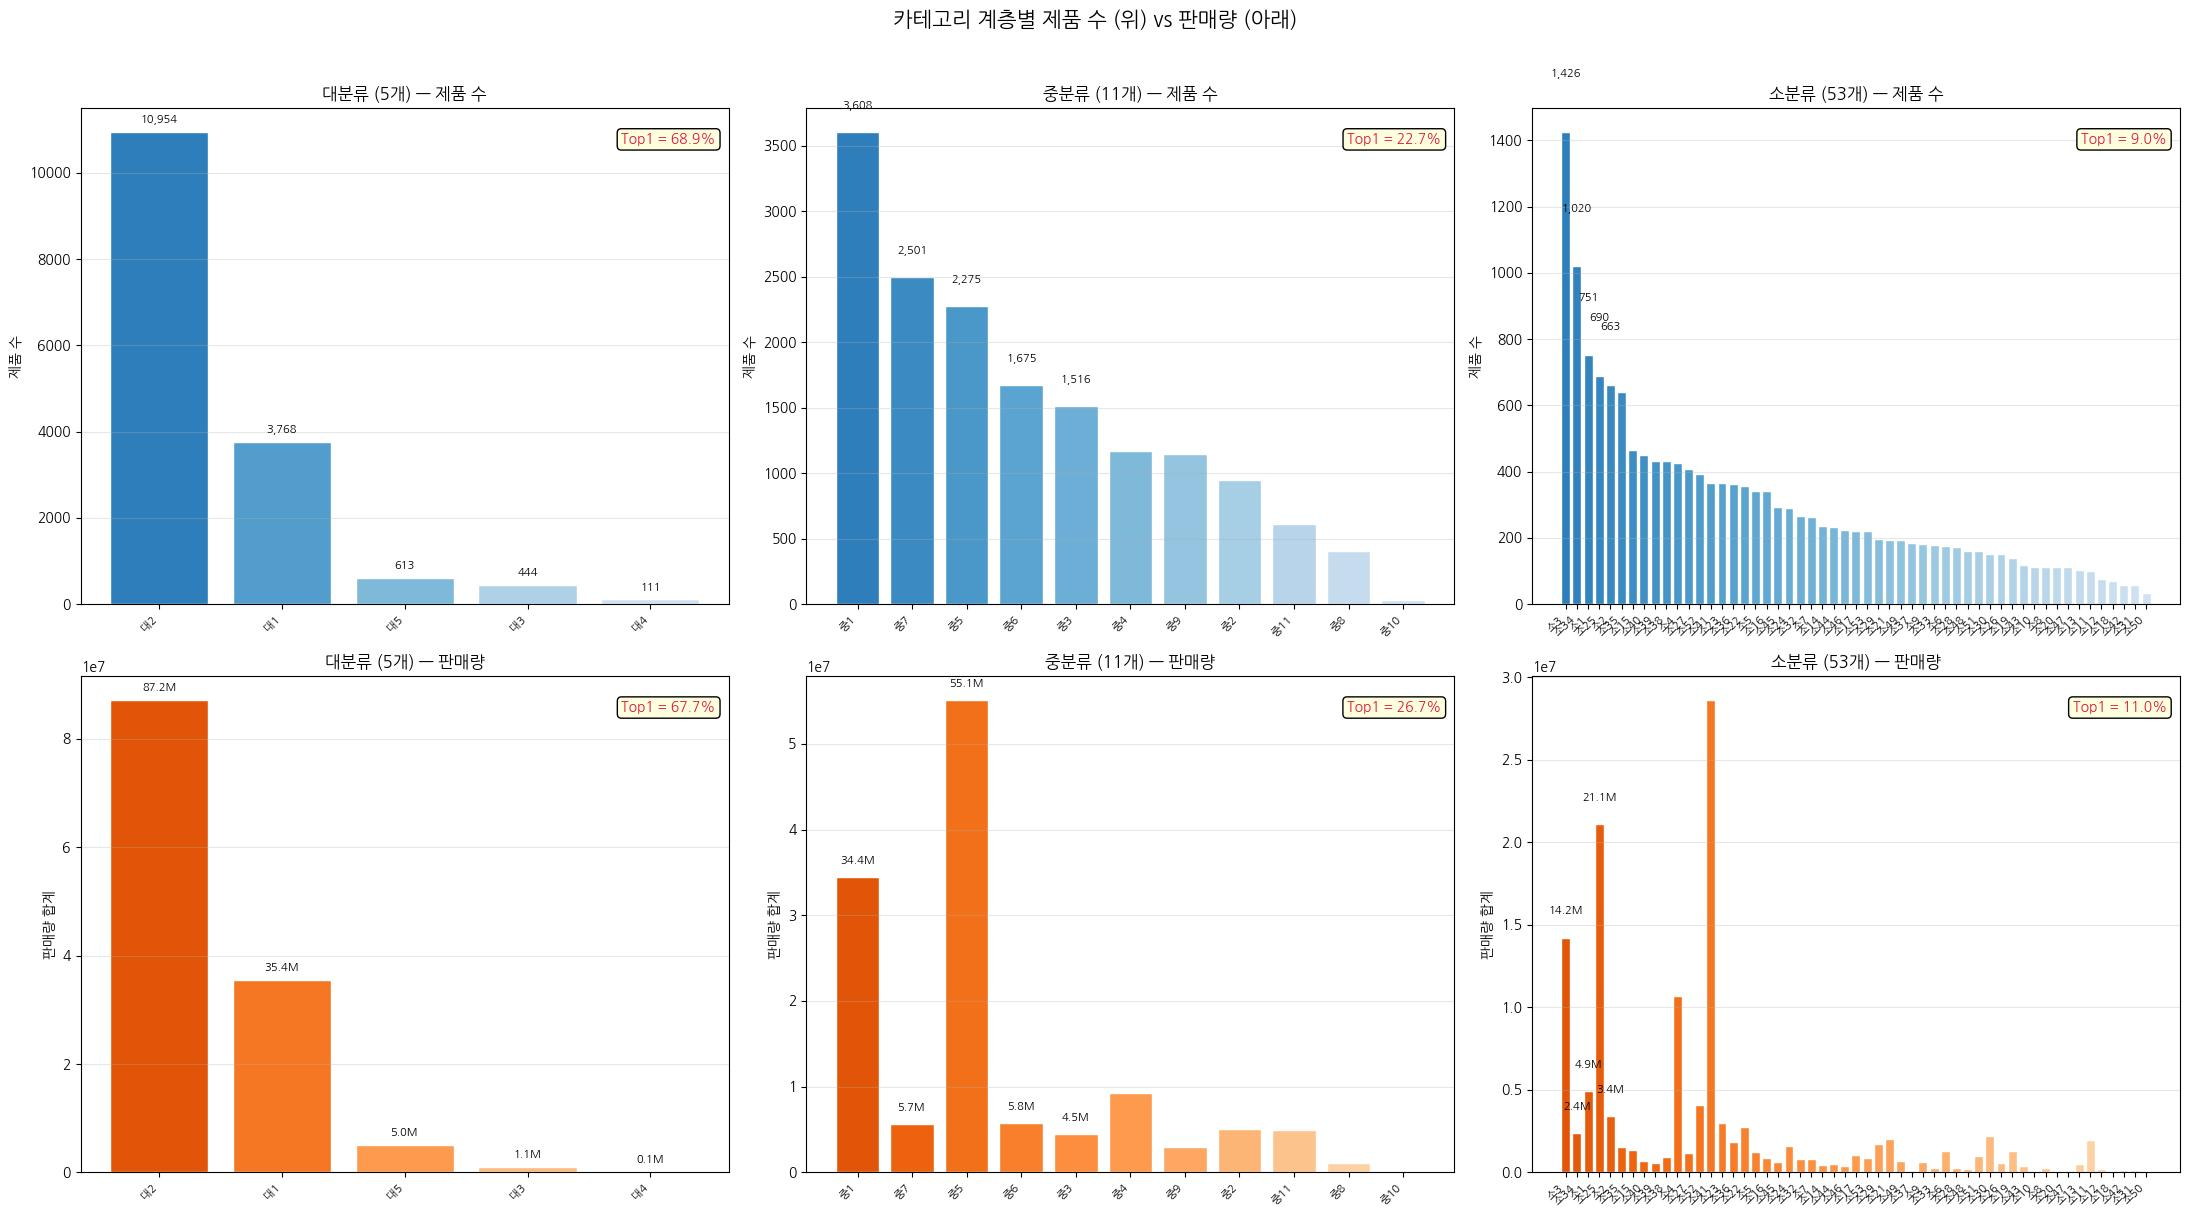

📌 카테고리별 제품 수 vs 판매량 비율 비교 — 상위 5개

[대분류]
      제품수  제품수비율(%)       판매량  판매비율(%)
대2  10954      68.9  87218401     67.7
대1   3768      23.7  35441662     27.5
대5    613       3.9   4961560      3.9
대3    444       2.8   1078827      0.8
대4    111       0.7     85411      0.1

[중분류]
     제품수  제품수비율(%)       판매량  판매비율(%)
중5  2275      14.3  55131807     42.8
중1  3608      22.7  34420592     26.7
중4  1168       7.4   9203982      7.1
중6  1675      10.5   5798762      4.5
중7  2501      15.7   5671077      4.4

[소분류]
      제품수  제품수비율(%)       판매량  판매비율(%)
소41   366       2.3  28636033     22.2
소25   690       4.3  21097753     16.4
소3   1426       9.0  14227803     11.0
소4    426       2.7  10673098      8.3
소1    751       4.7   4923380      3.8


In [5]:
# ── 카테고리별 제품 수(위) vs 판매량(아래) 2×3 시각화 ─────────────────────
# 위아래 비교하면 "제품은 많은데 안 팔리는 카테고리"를 한눈에 발견할 수 있음
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('카테고리 계층별 제품 수 (위) vs 판매량 (아래)',
             fontsize=15, fontweight='bold', y=1.01)

cats = ['대분류', '중분류', '소분류']

for col_idx, col in enumerate(cats):
    ax_top    = axes[0][col_idx]
    ax_bottom = axes[1][col_idx]

    product_cnt   = train[col].value_counts().sort_values(ascending=False)
    sales_by_cat  = train.groupby(col)[DATE_COLS].sum().sum(axis=1).reindex(product_cnt.index)
    n             = len(product_cnt)
    total_product = product_cnt.sum()
    total_sales   = sales_by_cat.sum()
    xlabels       = [cat_labels[col].get(name, name) for name in product_cnt.index]

    # ── 위: 제품 수 ────────────────────────────────────────────────────────
    colors_top = plt.cm.Blues_r([0.3 + 0.5 * i / max(n - 1, 1) for i in range(n)])
    bars_top   = ax_top.bar(range(n), product_cnt.values, color=colors_top, edgecolor='white')
    for j, (bar, val) in enumerate(zip(bars_top, product_cnt.values)):
        if j < 5:
            ax_top.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + total_product * 0.01,
                        f'{val:,}', ha='center', va='bottom', fontsize=8)
    top1_pct = product_cnt.values[0] / total_product * 100
    ax_top.text(0.98, 0.95, f'Top1 = {top1_pct:.1f}%',
                transform=ax_top.transAxes, ha='right', va='top', fontsize=10,
                color='crimson', bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))
    ax_top.set_title(f'{col} ({n}개) — 제품 수', fontsize=12, fontweight='bold')
    ax_top.set_ylabel('제품 수')
    ax_top.set_xticks(range(n))
    ax_top.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
    ax_top.grid(alpha=0.3, axis='y')

    # ── 아래: 판매량 ────────────────────────────────────────────────────────
    colors_bot = plt.cm.Oranges_r([0.3 + 0.5 * i / max(n - 1, 1) for i in range(n)])
    bars_bot   = ax_bottom.bar(range(n), sales_by_cat.values, color=colors_bot, edgecolor='white')
    for j, (bar, val) in enumerate(zip(bars_bot, sales_by_cat.values)):
        if j < 5:
            ax_bottom.text(bar.get_x() + bar.get_width()/2,
                           bar.get_height() + total_sales * 0.01,
                           f'{val/1e6:.1f}M', ha='center', va='bottom', fontsize=8)
    top1_sales_pct = sales_by_cat.values[0] / total_sales * 100
    ax_bottom.text(0.98, 0.95, f'Top1 = {top1_sales_pct:.1f}%',
                   transform=ax_bottom.transAxes, ha='right', va='top', fontsize=10,
                   color='crimson', bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))
    ax_bottom.set_title(f'{col} ({n}개) — 판매량', fontsize=12, fontweight='bold')
    ax_bottom.set_ylabel('판매량 합계')
    ax_bottom.set_xticks(range(n))
    ax_bottom.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
    ax_bottom.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ── 수치 요약 ──────────────────────────────────────────────────────────────
print('=' * 60)
print('📌 카테고리별 제품 수 vs 판매량 비율 비교 — 상위 5개')
print('=' * 60)
for col in cats:
    print(f'\n[{col}]')
    product_cnt  = train[col].value_counts()
    sales_by_cat = train.groupby(col)[DATE_COLS].sum().sum(axis=1)
    summary = pd.DataFrame({
        '제품수'        : product_cnt,
        '제품수비율(%)' : (product_cnt / product_cnt.sum() * 100).round(1),
        '판매량'        : sales_by_cat,
        '판매비율(%)'   : (sales_by_cat / sales_by_cat.sum() * 100).round(1),
    }).sort_values('판매량', ascending=False).head(5)
    summary.index = [cat_labels[col].get(i, i) for i in summary.index]
    print(summary.to_string())

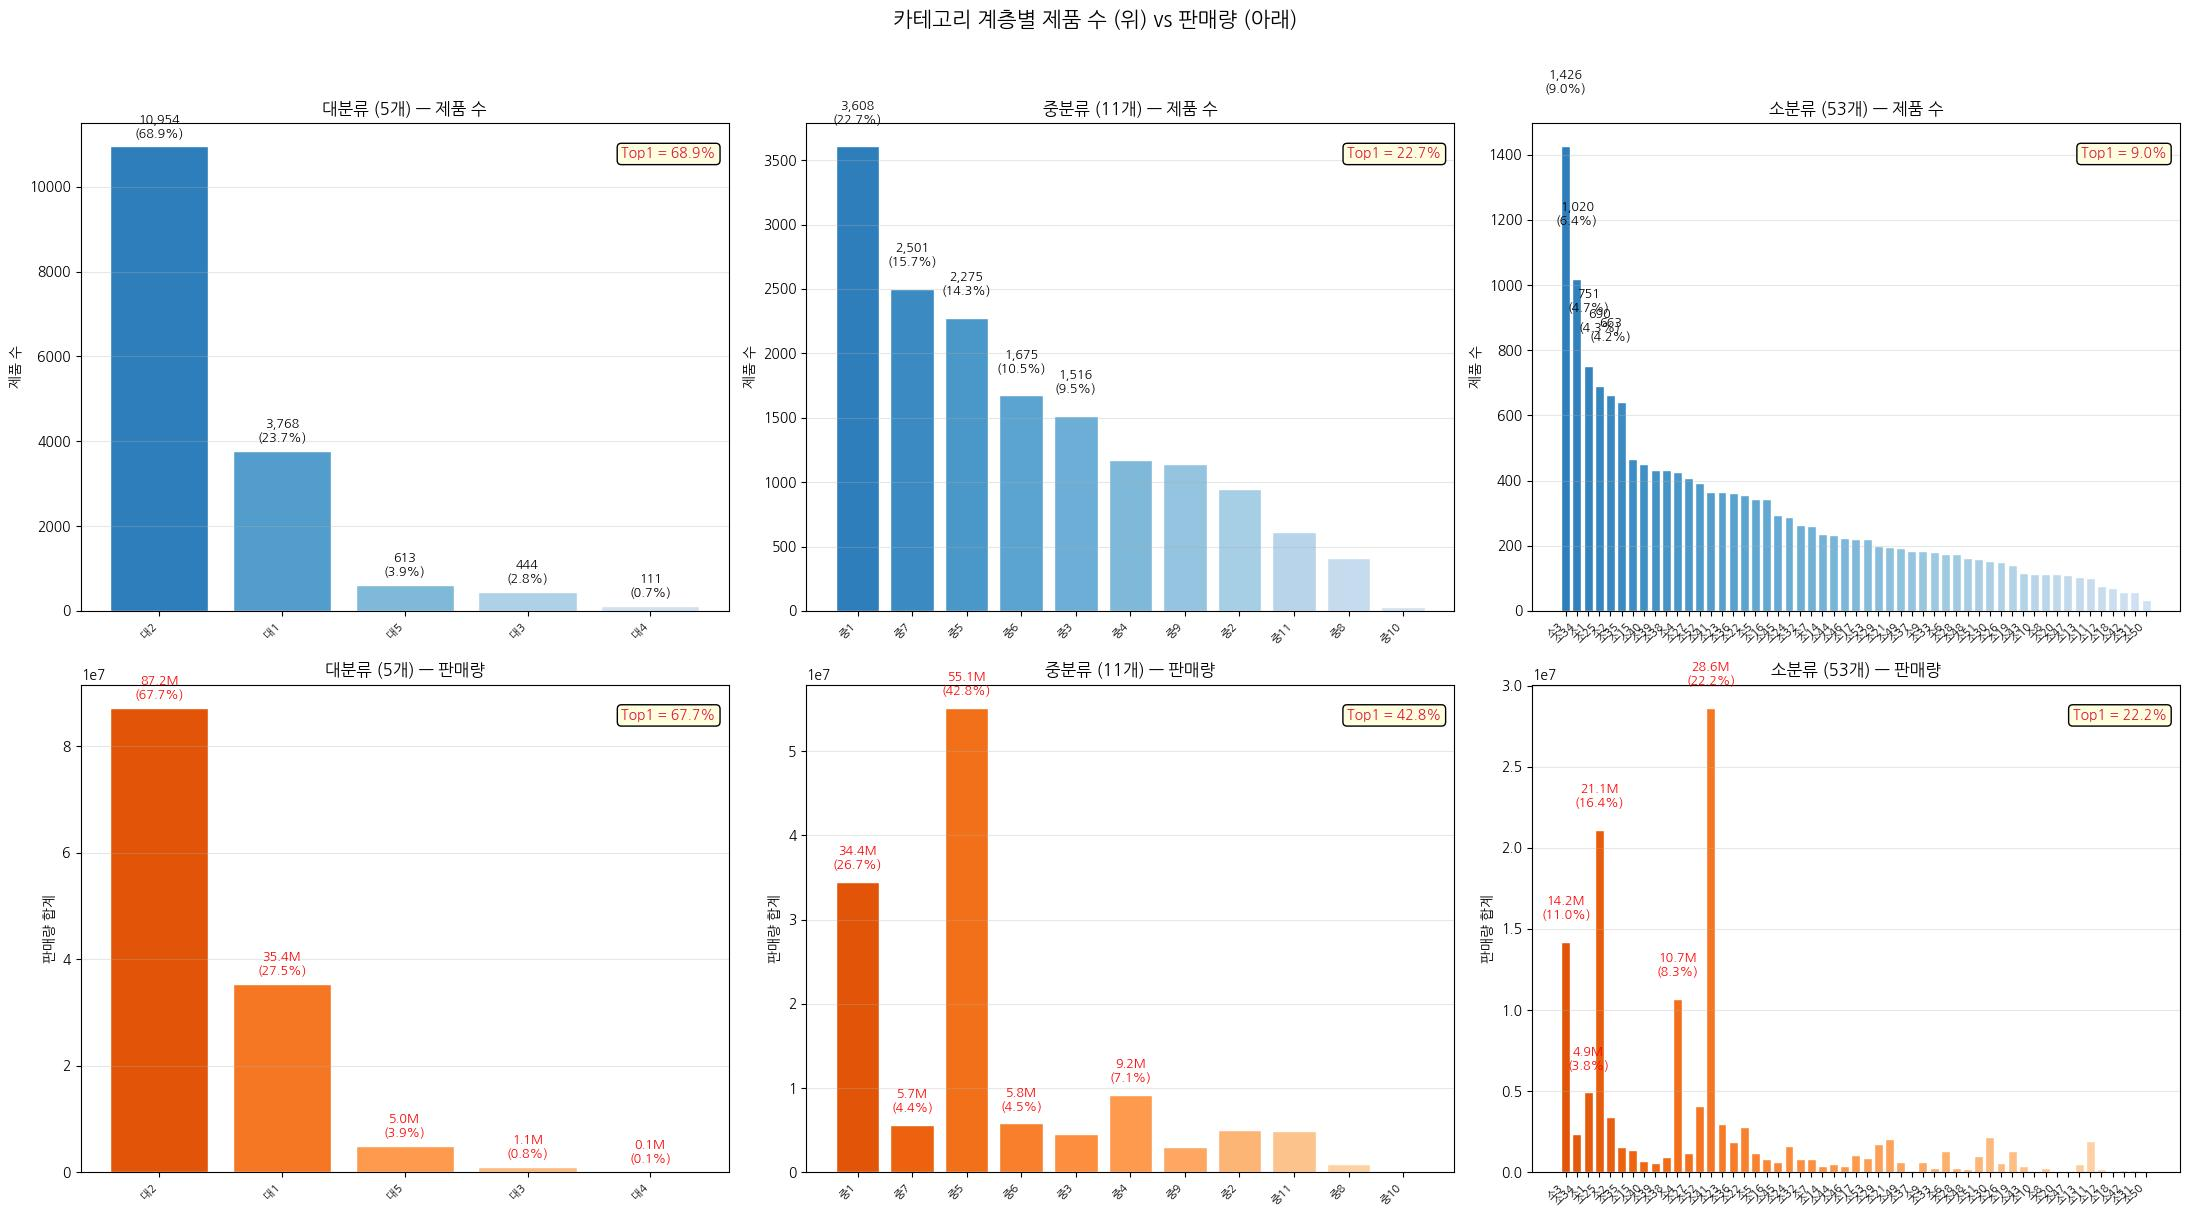

📌 카테고리별 제품 수 vs 판매량 비율 비교 — 상위 5개

[대분류]
      제품수  제품수비율(%)       판매량  판매비율(%)
대2  10954      68.9  87218401     67.7
대1   3768      23.7  35441662     27.5
대5    613       3.9   4961560      3.9
대3    444       2.8   1078827      0.8
대4    111       0.7     85411      0.1

[중분류]
     제품수  제품수비율(%)       판매량  판매비율(%)
중5  2275      14.3  55131807     42.8
중1  3608      22.7  34420592     26.7
중4  1168       7.4   9203982      7.1
중6  1675      10.5   5798762      4.5
중7  2501      15.7   5671077      4.4

[소분류]
      제품수  제품수비율(%)       판매량  판매비율(%)
소41   366       2.3  28636033     22.2
소25   690       4.3  21097753     16.4
소3   1426       9.0  14227803     11.0
소4    426       2.7  10673098      8.3
소1    751       4.7   4923380      3.8


In [6]:
# ── 카테고리별 제품 수(위) vs 판매량(아래) 2×3 시각화 ─────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('카테고리 계층별 제품 수 (위) vs 판매량 (아래)',
             fontsize=15, fontweight='bold', y=1.01)

cats = ['대분류', '중분류', '소분류']

for col_idx, col in enumerate(cats):
    ax_top    = axes[0][col_idx]
    ax_bottom = axes[1][col_idx]

    product_cnt   = train[col].value_counts().sort_values(ascending=False)
    sales_by_cat  = train.groupby(col)[DATE_COLS].sum().sum(axis=1).reindex(product_cnt.index)
    n             = len(product_cnt)
    total_product = product_cnt.sum()
    total_sales   = sales_by_cat.sum()
    xlabels       = [cat_labels[col].get(name, name) for name in product_cnt.index]

    # ── 위: 제품 수 ────────────────────────────────────────────────────────
    colors_top = plt.cm.Blues_r([0.3 + 0.5 * i / max(n - 1, 1) for i in range(n)])
    bars_top   = ax_top.bar(range(n), product_cnt.values, color=colors_top, edgecolor='white')
    
    for j, (bar, val) in enumerate(zip(bars_top, product_cnt.values)):
        if j < 5:  # 상위 5개까지만 텍스트 표시
            # 💡 [핵심 변경 포인트] 비율 계산 후 줄바꿈(\n)으로 추가
            pct = (val / total_product) * 100
            ax_top.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + total_product * 0.01,
                        f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
            
    top1_pct = product_cnt.values[0] / total_product * 100
    ax_top.text(0.98, 0.95, f'Top1 = {top1_pct:.1f}%',
                transform=ax_top.transAxes, ha='right', va='top', fontsize=10,
                color='crimson', bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))
    ax_top.set_title(f'{col} ({n}개) — 제품 수', fontsize=12, fontweight='bold')
    ax_top.set_ylabel('제품 수')
    ax_top.set_xticks(range(n))
    ax_top.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
    ax_top.grid(alpha=0.3, axis='y')
    
    # ── 아래: 판매량 ────────────────────────────────────────────────────────
    colors_bot = plt.cm.Oranges_r([0.3 + 0.5 * i / max(n - 1, 1) for i in range(n)])
    bars_bot   = ax_bottom.bar(range(n), sales_by_cat.values, color=colors_bot, edgecolor='white')
    
    # 💡 [핵심 변경 포인트 1] 판매량 기준으로 진짜 Top 5인 카테고리를 미리 뽑아둠!
    top5_sales_cats = sales_by_cat.sort_values(ascending=False).head(5).index

    for j, (bar, val) in enumerate(zip(bars_bot, sales_by_cat.values)):
        current_cat = sales_by_cat.index[j] # 지금 순서를 돌고 있는 막대의 카테고리 이름
        
        # 무조건 왼쪽 5개가 아니라, 현재 카테고리가 '판매량 Top 5' 안에 속할 때만 %를 달아라!
        if current_cat in top5_sales_cats: 
            pct = (val / total_sales) * 100
            ax_bottom.text(bar.get_x() + bar.get_width()/2,
                           bar.get_height() + total_sales * 0.01,
                           f'{val/1e6:.1f}M\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9,
                           color='red', fontweight='bold') # 👈 눈에 확 띄게 빨간색 굵은 글씨로 포인트!
                           
    # 💡 [핵심 변경 포인트 2] 무조건 0번 자리가 아니라, .max()를 써서 진짜 판매량 1등을 찾는다!
    real_top1_sales = sales_by_cat.max()
    top1_sales_pct = (real_top1_sales / total_sales) * 100
    
    ax_bottom.text(0.98, 0.95, f'Top1 = {top1_sales_pct:.1f}%',
                   transform=ax_bottom.transAxes, ha='right', va='top', fontsize=10,
                   color='crimson', bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))
    ax_bottom.set_title(f'{col} ({n}개) — 판매량', fontsize=12, fontweight='bold')
    ax_bottom.set_ylabel('판매량 합계')
    ax_bottom.set_xticks(range(n))
    ax_bottom.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
    ax_bottom.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ── 수치 요약 ──────────────────────────────────────────────────────────────
print('=' * 60)
print('📌 카테고리별 제품 수 vs 판매량 비율 비교 — 상위 5개')
print('=' * 60)
for col in cats:
    print(f'\n[{col}]')
    product_cnt  = train[col].value_counts()
    sales_by_cat = train.groupby(col)[DATE_COLS].sum().sum(axis=1)
    summary = pd.DataFrame({
        '제품수'        : product_cnt,
        '제품수비율(%)' : (product_cnt / product_cnt.sum() * 100).round(1),
        '판매량'        : sales_by_cat,
        '판매비율(%)'   : (sales_by_cat / sales_by_cat.sum() * 100).round(1),
    }).sort_values('판매량', ascending=False).head(5)
    summary.index = [cat_labels[col].get(i, i) for i in summary.index]
    print(summary.to_string())

#### 💬 2-1 해석 — 카테고리 불균형이 모델 설계에 미치는 영향

| 카테고리 | 제품수 비율 | 판매 비율 | 해석 |
|---------|-----------|---------|------|
| 대분류 대2 | ~69% | ~68% | 두 비율 유사 → 카테고리 간 불균형 적음 |
| 중분류 상위 | 낮음 | 높음 | 제품은 적은데 판매 압도적 → 핵심 카테고리 |
| 소분류 상위 | 매우 낮음 | 높음 | 소수 스타 카테고리 존재 |

**→ 모델링 활용:** 카테고리별 판매 편차가 크므로 임베딩 레이어로 카테고리 정보를 강하게 반영해야 함

### 2-2. 판매량 분포 — Long Tail + 로렌츠 곡선

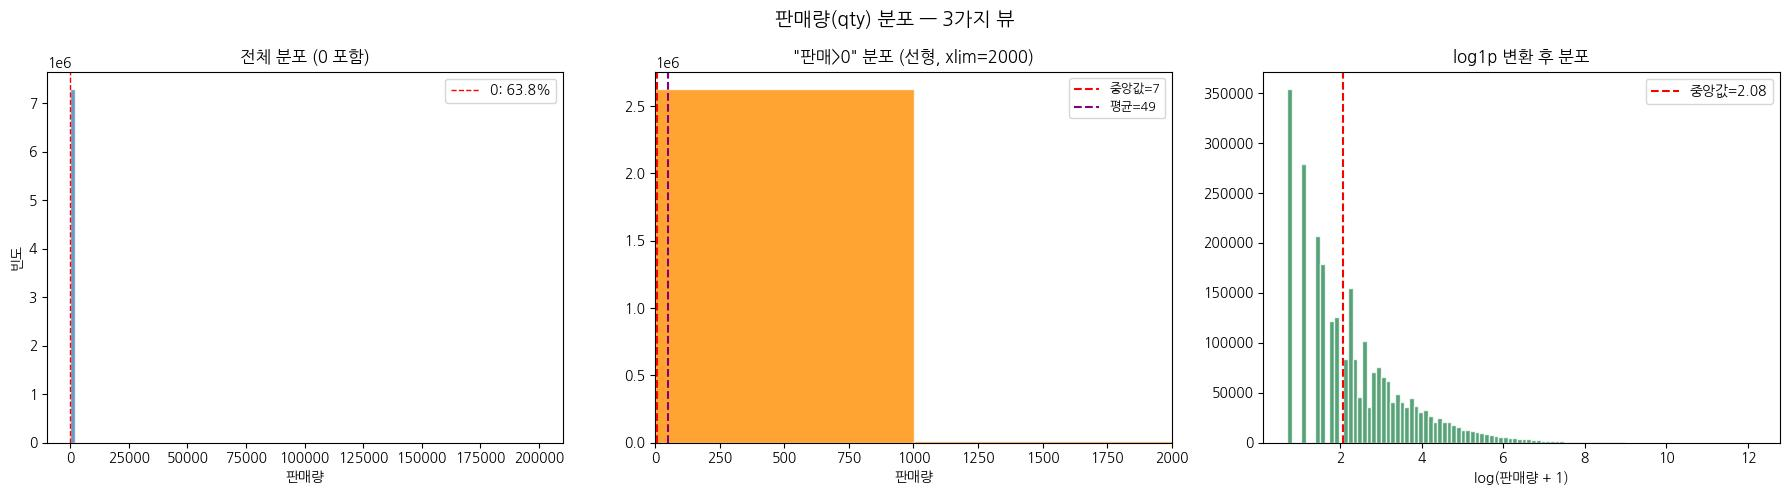


💡 스케일 압축: 원본 0~200,420 → log 변환 후 0~12.2
   압축 비율: 16417배 축소


In [7]:
# ── 판매량 분포 3가지 뷰 ──────────────────────────────────────────────────
# 뷰1: 전체 분포(0 포함) / 뷰2: 판매>0만 (선형) / 뷰3: log1p 변환 후
# → 세 뷰를 나란히 보면 "왜 log 변환이 필요한지" 눈으로 이해됨
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('판매량(qty) 분포 — 3가지 뷰', fontsize=14, fontweight='bold')

qty_nonzero = qty_all[qty_all > 0]

ax = axes[0]
ax.hist(qty_all, bins=100, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('전체 분포 (0 포함)')
ax.set_xlabel('판매량'); ax.set_ylabel('빈도')
ax.axvline(0, color='red', ls='--', lw=1, label=f'0: {(qty_all==0).mean():.1%}')
ax.legend()

ax = axes[1]
ax.hist(qty_nonzero, bins=200, color='darkorange', alpha=0.8, edgecolor='white')
ax.set_xlim(0, 2000)
ax.set_title('"판매>0" 분포 (선형, xlim=2000)')
ax.set_xlabel('판매량')
ax.axvline(np.median(qty_nonzero), color='red',    ls='--', lw=1.5,
           label=f'중앙값={np.median(qty_nonzero):.0f}')
ax.axvline(qty_nonzero.mean(),    color='purple', ls='--', lw=1.5,
           label=f'평균={qty_nonzero.mean():.0f}')
ax.legend(fontsize=9)

ax = axes[2]
qty_log = np.log1p(qty_nonzero)
ax.hist(qty_log, bins=100, color='seagreen', alpha=0.8, edgecolor='white')
ax.set_title('log1p 변환 후 분포')
ax.set_xlabel('log(판매량 + 1)')
ax.axvline(np.median(qty_log), color='red', ls='--', lw=1.5,
           label=f'중앙값={np.median(qty_log):.2f}')
ax.legend()

plt.tight_layout()
plt.show()
print(f'\n💡 스케일 압축: 원본 0~{qty_all.max():,} → log 변환 후 0~{np.log1p(qty_all.max()):.1f}')
print(f'   압축 비율: {qty_all.max() / np.log1p(qty_all.max()):.0f}배 축소')

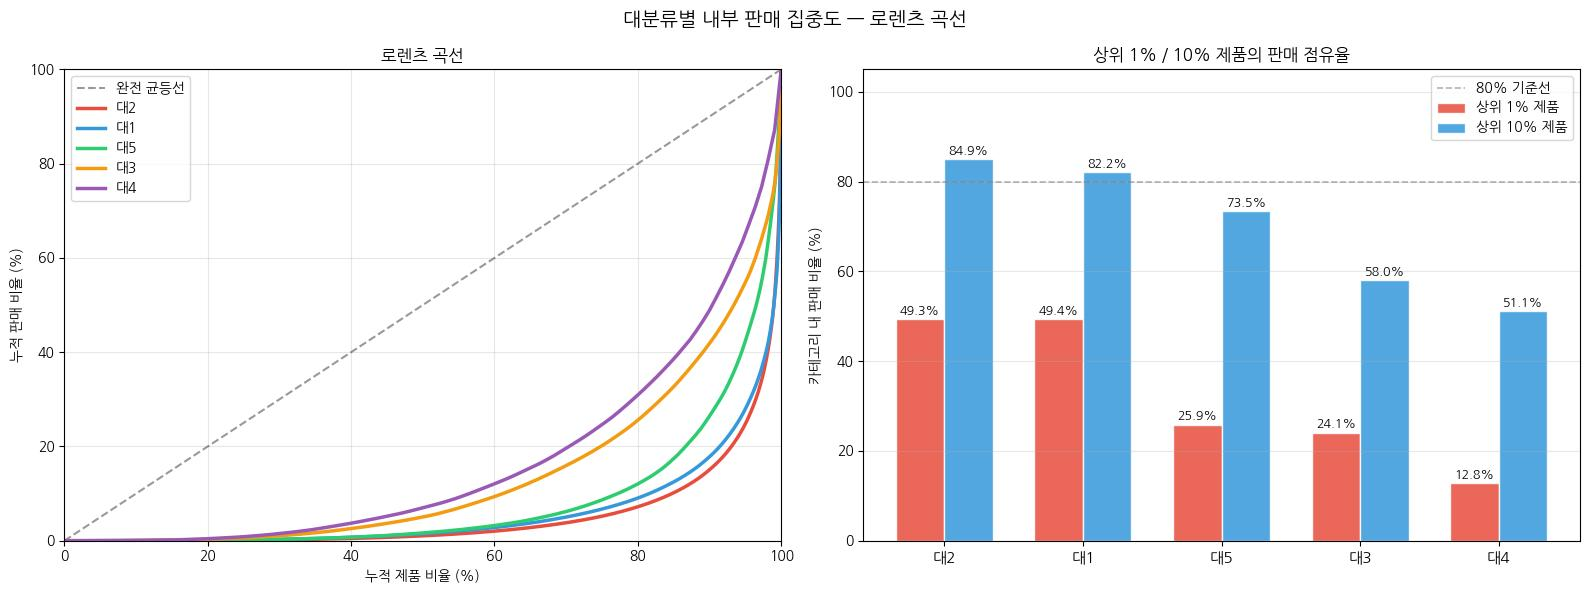

In [8]:
# ── 로렌츠 곡선 — 카테고리 내부도 Long Tail인지 확인 ─────────────────────
# X축=누적 제품 비율, Y축=누적 판매 비율
# 대각선에 가까울수록 균등, 아래로 처질수록 소수 제품이 판매를 독식함
train['total_sales'] = train[DATE_COLS].sum(axis=1)
cats_ordered = train.groupby('대분류')['total_sales'].sum().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('대분류별 내부 판매 집중도 — 로렌츠 곡선', fontsize=14, fontweight='bold')
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

ax = axes[0]
ax.plot([0, 100], [0, 100], 'k--', lw=1.5, alpha=0.4, label='완전 균등선')
for i, cat in enumerate(cats_ordered):
    subset = train[train['대분류'] == cat]['total_sales'].sort_values(ascending=True).values
    cumsum = np.cumsum(subset) / subset.sum() * 100
    x      = np.linspace(0, 100, len(cumsum))
    label  = cat_labels['대분류'].get(cat, cat)
    ax.plot(x, cumsum, color=colors[i], linewidth=2.5, label=label)
ax.set_xlabel('누적 제품 비율 (%)')
ax.set_ylabel('누적 판매 비율 (%)')
ax.set_title('로렌츠 곡선')
ax.legend(); ax.grid(alpha=0.3)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)

ax = axes[1]
labels_list = [cat_labels['대분류'].get(c, c) for c in cats_ordered]
top1_pcts, top10_pcts = [], []
for cat in cats_ordered:
    subset = train[train['대분류'] == cat]['total_sales'].sort_values(ascending=False)
    total  = subset.sum()
    top1_pcts.append(subset.iloc[:max(1, int(len(subset)*0.01))].sum() / total * 100)
    top10_pcts.append(subset.iloc[:max(1, int(len(subset)*0.1))].sum() / total * 100)
x = np.arange(len(labels_list)); width = 0.35
bars1 = ax.bar(x - width/2, top1_pcts,  width, label='상위 1% 제품',
               color='#e74c3c', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, top10_pcts, width, label='상위 10% 제품',
               color='#3498db', alpha=0.85, edgecolor='white')
for bar, val in zip(bars1, top1_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, top10_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.axhline(80, color='gray', linestyle='--', lw=1.2, alpha=0.6, label='80% 기준선')
ax.set_xticks(x); ax.set_xticklabels(labels_list, fontsize=11)
ax.set_ylabel('카테고리 내 판매 비율 (%)')
ax.set_title('상위 1% / 10% 제품의 판매 점유율')
ax.legend(); ax.grid(alpha=0.3, axis='y'); ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()
train.drop(columns=['total_sales'], inplace=True)

#### 💬 2-2 해석

**Long Tail 구조 확인:**
- 전체의 63.8%가 0 → 왼쪽에 거대한 뭉치
- 판매>0인 날만 봐도 소수 인기 제품이 판매를 독식 (최대 20만 개 이상)
- log1p 변환 후 종 모양에 근접 → 모든 제품이 비슷한 영향력을 가질 수 있음

| 비교 | 변환 전 | 변환 후 |
|------|--------|--------|
| 범위 | 0 ~ 200,000+ | 0 ~ 12 |
| 인기 제품 영향력 | 학습 지배 | 균등화됨 |

> **역변환:** 예측 완료 후 `np.expm1(y)`로 원래 단위(개) 복원  
> **→ STEP 3 전처리에서 log1p 변환 적용 결정**

### 2-3. 일별 판매 트렌드 — 급락 구간 포함

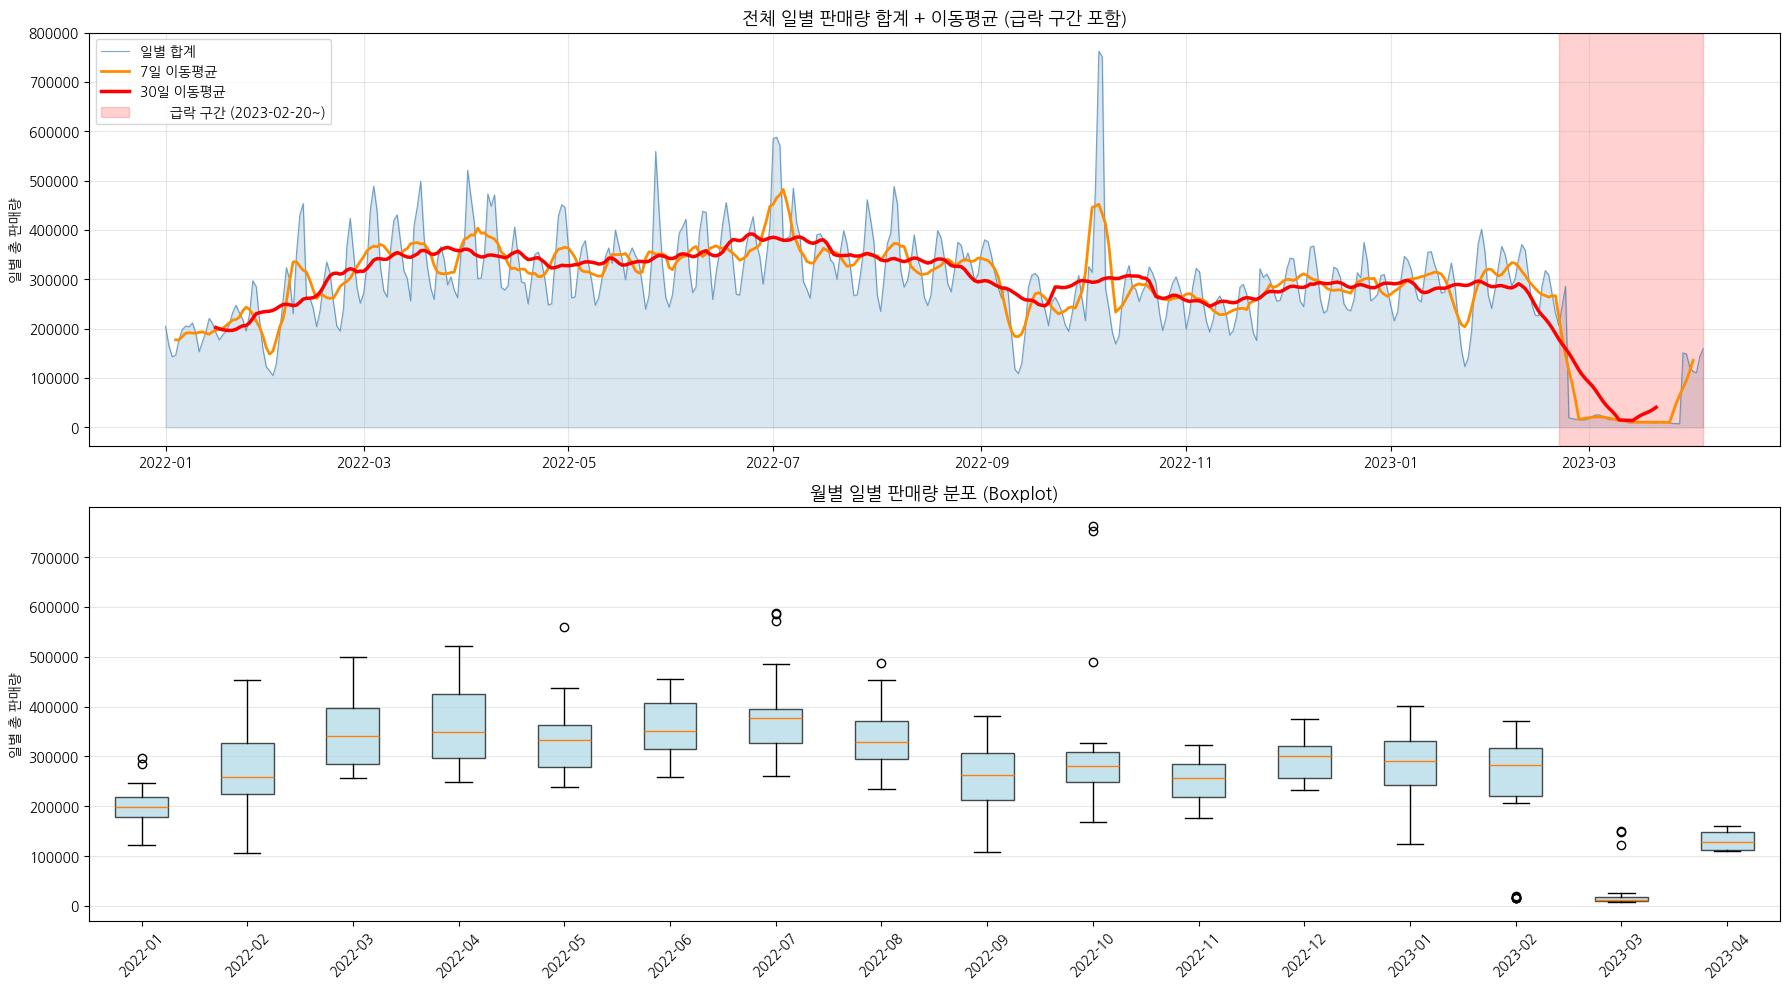


📊 급락 구간 분석
  정상 구간 일평균 : 305,103
  급락 구간 일평균 : 49,274  (16.2%)
  → STEP 3-0에서 3가지 처리 방법 중 선택


In [9]:
# ── 일별 판매 트렌드 계산 ─────────────────────────────────────────────────
# ⚠️ daily_total, ma30, upper, lower 변수는
#    2-5 Spike 탐지와 STEP 3-0 급락 처리에서 재사용됩니다.

daily_total = train[DATE_COLS].sum(axis=0)
daily_total.index = pd.to_datetime(daily_total.index)

ma7   = daily_total.rolling(7,  center=True).mean()
ma30  = daily_total.rolling(30, center=True).mean()
std30 = daily_total.rolling(30, center=True).std()
upper = ma30 + 2 * std30
lower = ma30 - 2 * std30

# 급락 구간 정의 (2-3 시각화 + STEP 3-0에서 처리)
CRASH_START = pd.Timestamp('2023-02-20')
CRASH_END   = pd.Timestamp('2023-04-04')

# ── 트렌드 + 월별 박스플롯 시각화 ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

ax = axes[0]
ax.fill_between(daily_total.index, daily_total.values, alpha=0.2, color='steelblue')
ax.plot(daily_total.index, daily_total.values, color='steelblue', lw=0.8, alpha=0.7, label='일별 합계')
ax.plot(ma7.index,  ma7.values,  color='darkorange', lw=2,   label='7일 이동평균')
ax.plot(ma30.index, ma30.values, color='red',        lw=2.5, label='30일 이동평균')
ax.axvspan(CRASH_START, CRASH_END, alpha=0.18, color='red',
           label=f'⚠️ 급락 구간 ({CRASH_START.date()}~)')
ax.set_title('전체 일별 판매량 합계 + 이동평균 (급락 구간 포함)', fontsize=13)
ax.set_ylabel('일별 총 판매량')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

ax = axes[1]
temp = pd.DataFrame({'date': daily_total.index, 'total': daily_total.values})
temp['yearmonth'] = temp['date'].dt.strftime('%Y-%m')
month_data   = [group['total'].values for _, group in temp.groupby('yearmonth')]
month_labels = list(temp['yearmonth'].unique())
ax.boxplot(month_data, labels=month_labels, patch_artist=True,
           boxprops=dict(facecolor='lightblue', alpha=0.7))
ax.set_title('월별 일별 판매량 분포 (Boxplot)', fontsize=13)
ax.set_ylabel('일별 총 판매량')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 급락 구간 수치 확인
normal_avg = daily_total[daily_total.index < CRASH_START].mean()
crash_avg  = daily_total[daily_total.index >= CRASH_START].mean()
print(f'\n📊 급락 구간 분석')
print(f'  정상 구간 일평균 : {normal_avg:,.0f}')
print(f'  급락 구간 일평균 : {crash_avg:,.0f}  ({crash_avg/normal_avg:.1%})')
print(f'  → STEP 3-0에서 3가지 처리 방법 중 선택')

#### 💬 2-3 해석

**2023-02-20 이후 급락:**
- 정상 구간 대비 판매량이 대폭 감소하는 구간 발견
- 데이터 수집 오류, 플랫폼 이슈, 실제 시장 변화 중 하나일 수 있음
- **STEP 3-0에서 3가지 방법으로 처리:** 제외 / 보간 / 플래그 중 선택

**계절성 패턴:**
- 10월~12월 판매 피크 → 연말 쇼핑 시즌
- 2월 연중 최저 → 명절 이후 소비 침체

**→ 모델링 활용:** `rolling_7`, `rolling_30` lag 피처 추가 근거

### 2-4. 요일·월별 판매 패턴

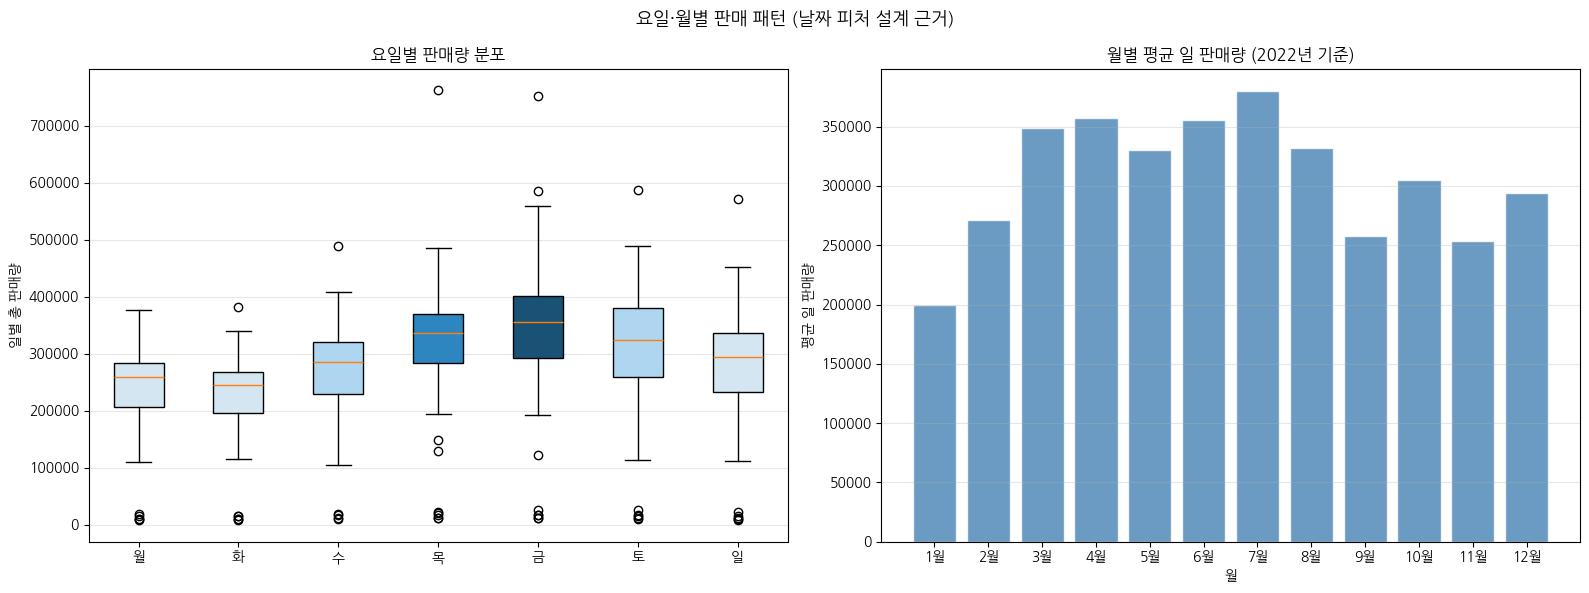

In [10]:
# ── 요일·월별 판매 패턴 시각화 ────────────────────────────────────────────
# 목적: 날짜 피처(day_of_week, month, is_weekend)를 추가할 근거 확보
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('요일·월별 판매 패턴 (날짜 피처 설계 근거)', fontsize=13, fontweight='bold')

temp = pd.DataFrame({'date': pd.to_datetime(daily_total.index), 'total': daily_total.values})
temp['day_of_week'] = temp['date'].dt.dayofweek
temp['month']       = temp['date'].dt.month
dow_labels = ['월', '화', '수', '목', '금', '토', '일']

ax = axes[0]
dow_data = [temp[temp['day_of_week'] == d]['total'].values for d in range(7)]
bp = ax.boxplot(dow_data, labels=dow_labels, patch_artist=True)
colors_dow = ['#d4e6f1','#d4e6f1','#aed6f1','#2e86c1','#1a5276','#aed6f1','#d4e6f1']
for patch, c in zip(bp['boxes'], colors_dow):
    patch.set_facecolor(c)
ax.set_title('요일별 판매량 분포')
ax.set_ylabel('일별 총 판매량')
ax.grid(alpha=0.3, axis='y')

ax = axes[1]
temp_2022   = temp[temp['date'].dt.year == 2022]
monthly_avg = temp_2022.groupby('month')['total'].mean()
month_kor   = ['1월','2월','3월','4월','5월','6월','7월','8월','9월','10월','11월','12월']
ax.bar(monthly_avg.index, monthly_avg.values, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('월별 평균 일 판매량 (2022년 기준)')
ax.set_xlabel('월'); ax.set_ylabel('평균 일 판매량')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_kor)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#### 💬 2-4 해석

**요일 패턴:** 목·금요일 판매가 높음 ????
- 온라인 쇼핑 특성상 퇴근 전후 구매 집중
- **→ `day_of_week`, `is_weekend` 피처 추가**

**월별 패턴:** ???????????????
- **→ `month`, `quarter` 피처 추가**

### 2-5. Spike(이상치) 탐지 — MA30 ± 2σ 기준

감지된 Spike 날짜 수: 16일
날짜 목록 (앞 10개): ['2022-02-10', '2022-02-11', '2022-04-01', '2022-04-29', '2022-04-30', '2022-05-27', '2022-07-01', '2022-07-02', '2022-07-03', '2022-08-06']


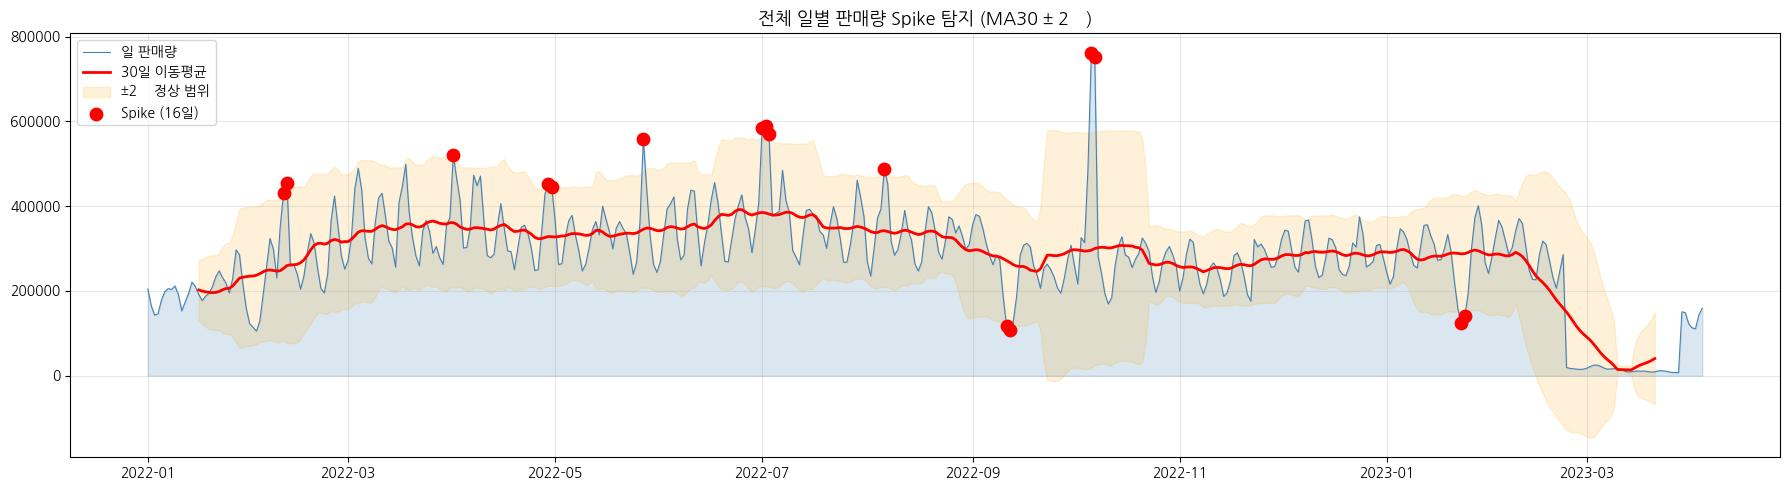

In [11]:
# ── Spike 탐지 (MA30 ± 2σ) ────────────────────────────────────────────────
# 정상 범위(MA30 ± 2σ)를 벗어나는 날 = Spike
# ⚠️ ma30, upper, lower 는 2-3에서 이미 계산됨
spike_dates = daily_total[(daily_total > upper) | (daily_total < lower)].index

print(f'감지된 Spike 날짜 수: {len(spike_dates)}일')
print(f'날짜 목록 (앞 10개): {[str(d.date()) for d in spike_dates[:10]]}')

# ── Spike 시각화 ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 5))
ax.fill_between(daily_total.index, daily_total, alpha=0.2, color='steelblue')
ax.plot(daily_total.index, daily_total, lw=0.8, color='steelblue', label='일 판매량')
ax.plot(ma30.index, ma30.values, 'r-', lw=2, label='30일 이동평균')
ax.fill_between(ma30.index, lower, upper, alpha=0.15, color='orange', label='±2σ 정상 범위')
ax.scatter(spike_dates, daily_total[spike_dates], color='red', zorder=5, s=80,
           label=f'Spike ({len(spike_dates)}일)')
ax.set_title('전체 일별 판매량 Spike 탐지 (MA30 ± 2σ)', fontsize=13)
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 💬 2-5 해석 — Spike 처리 전략

**Spike = 실제 이벤트(세일, 라이브 커머스)일 가능성이 높음** → 무조건 제거는 위험

처리 전략: **클리핑(Clipping)** — 완전 제거 대신 "중앙값 × 20" 상한선으로 깎기
- 패턴은 유지하되, 극단값이 학습을 지배하는 것을 방지
- 중앙값 × 20 근거: 정상 판매일의 최대치가 평균의 10~15배 수준임을 감안해 여유 있게 설정

> **→ STEP 3-1에서 클리핑 적용**

### 2-6. 0의 두 종류 구분 — 구조적 0 vs 진짜 0

| 종류 | 언제 발생? | 실제 의미 | 학습에 포함? |
|------|----------|---------|------------|
| **구조적 0** | 제품 출시 전, 단종 후 | 이 제품은 아직 존재하지 않음 | ❌ 마스킹 |
| **진짜 0** | 출시 후 그날 판매 없음 | 오늘은 아무도 안 샀음 | ✅ 포함 |

In [12]:
# ── 구조적 0 vs 진짜 0 분류 ───────────────────────────────────────────────
# ⚠️ 이 셀에서 만들어지는 변수들은 STEP 3-4(구조적 0 마스킹)에서 재사용됩니다.
#    → first_sale_date : 제품별 첫 판매일
#    → last_sale_date  : 제품별 마지막 판매일
#    → has_sales       : 한 번이라도 판매된 제품 여부 (True/False)

qty_arr   = train[DATE_COLS]
has_sales = (qty_arr > 0).any(axis=1)   # 한 번이라도 팔린 제품

# 첫 판매일 / 마지막 판매일 계산
first_sale_col = (qty_arr > 0).idxmax(axis=1)
last_sale_col  = (qty_arr > 0).iloc[:, ::-1].idxmax(axis=1)

train['first_sale_date'] = pd.to_datetime(first_sale_col)
train['last_sale_date']  = pd.to_datetime(last_sale_col)
train.loc[~has_sales, ['first_sale_date', 'last_sale_date']] = pd.NaT

# 구조적 0 추정 (출시 전 + 단종 후 90일 기준)
total_cells = len(train) * len(DATE_COLS)
sold_cells  = (qty_arr > 0).sum().sum()
date_index  = pd.to_datetime(DATE_COLS)

structural_zeros = 0
for _, row in train[has_sales].iterrows():
    pre_launch = (date_index < row['first_sale_date']).sum()
    post_disc  = (date_index > row['last_sale_date'] + pd.Timedelta(days=90)).sum()
    structural_zeros += pre_launch + post_disc

real_zeros = total_cells - sold_cells - structural_zeros

print('=' * 55)
print('📊 0의 두 종류 분류 결과')
print('=' * 55)
print(f'  전체 셀 수            : {total_cells:>10,}개 (100.0%)')
print(f'  실제 판매 (qty > 0)   : {sold_cells:>10,}개 ({sold_cells/total_cells:.1%})')
print(f'  진짜 0 (출시 후 미판매): {real_zeros:>10,}개 ({real_zeros/total_cells:.1%})')
print(f'  구조적 0 (출시 전/단종): {structural_zeros:>10,}개 ({structural_zeros/total_cells:.1%})')
print()
print(f'  한 번도 안 팔린 제품  : {(~has_sales).sum():>10,}개')

📊 0의 두 종류 분류 결과
  전체 셀 수            :  7,293,510개 (100.0%)
  실제 판매 (qty > 0)   :  2,640,650개 (36.2%)
  진짜 0 (출시 후 미판매):  2,436,264개 (33.4%)
  구조적 0 (출시 전/단종):  2,216,596개 (30.4%)

  한 번도 안 팔린 제품  :         85개


#### 💬 2-6 해석

**구조적 0이 위험한 이유:**
- 모델 입장에서 "출시 전 0" 과 "출시 후 안 팔린 0"을 구분할 수 없음
- 구분 없이 학습시키면 모델이 "이 제품은 원래 안 팔리는 제품"이라고 잘못 학습

**처리 방법:**
- `first_sale_date` 이전 → 마스킹 (학습에서 제외)
- `last_sale_date + 90일` 이후 → 마스킹

> **→ STEP 3-4에서 `first_sale_date`, `last_sale_date` 변수를 재사용해 마스킹 적용**

### 2-7. 브랜드 검색량 — 판매 예측에 도움이 되나?

In [13]:
# ── 검색량 기본 정보 + 시차별 상관관계 분석 ───────────────────────────────
# 핵심 질문: "검색량이 N일 뒤의 판매량을 예측하는가?"
kw_values = keyword[KW_COLS].values.flatten()
kw_values = kw_values[~np.isnan(kw_values)]

print('=' * 55)
print('📊 brand_keyword_cnt.csv 기본 정보')
print('=' * 55)
print(f"  브랜드 수        : {keyword['브랜드'].nunique():,}개")
print(f'  날짜 수          : {len(KW_COLS)}일 ({KW_COLS[0]} ~ {KW_COLS[-1]})')
print(f'  0인 셀 비율      : {(kw_values == 0).mean():.1%}')
print(f'  검색량 평균       : {kw_values[kw_values>0].mean():.1f}')
print(f'  검색량 최대       : {kw_values.max():.0f}')

# 시차별 평균 상관계수
brand_qty_wide = train.groupby('브랜드')[DATE_COLS].sum()
common_n = min(len(DATE_COLS), len(KW_COLS))
kw_wide  = keyword.set_index('브랜드')[KW_COLS[:common_n]].reindex(brand_qty_wide.index).fillna(0)

print('\n검색량과 판매량의 시차별 평균 상관계수:')
print('(해석 기준: |r| > 0.3 → 유용 / 0.1~0.3 → 보조적 / < 0.1 → 미약)')
print('-' * 50)
for lag in [0, 1, 3, 7, 14]:
    corrs = []
    for brand in brand_qty_wide.index:
        qs = brand_qty_wide.loc[brand].values[:common_n]
        ks = kw_wide.loc[brand].values
        q, k = (qs, ks) if lag == 0 else (qs[lag:], ks[:-lag])
        if k.std() > 0 and q.std() > 0:
            corrs.append(np.corrcoef(k, q)[0, 1])
    mean_r = np.mean(corrs)
    bar = '█' * int(abs(mean_r) * 100)
    print(f'  lag_{lag:2d}: {mean_r:+.4f}  {bar}')

📊 brand_keyword_cnt.csv 기본 정보
  브랜드 수        : 3,170개
  날짜 수          : 459일 (2022-01-01 ~ 2023-04-04)
  0인 셀 비율      : 21.7%
  검색량 평균       : 6.2
  검색량 최대       : 13383

검색량과 판매량의 시차별 평균 상관계수:
(해석 기준: |r| > 0.3 → 유용 / 0.1~0.3 → 보조적 / < 0.1 → 미약)
--------------------------------------------------
  lag_ 0: -0.0029  
  lag_ 1: +0.0140  █
  lag_ 3: +0.0204  ██
  lag_ 7: -0.0090  
  lag_14: -0.0073  


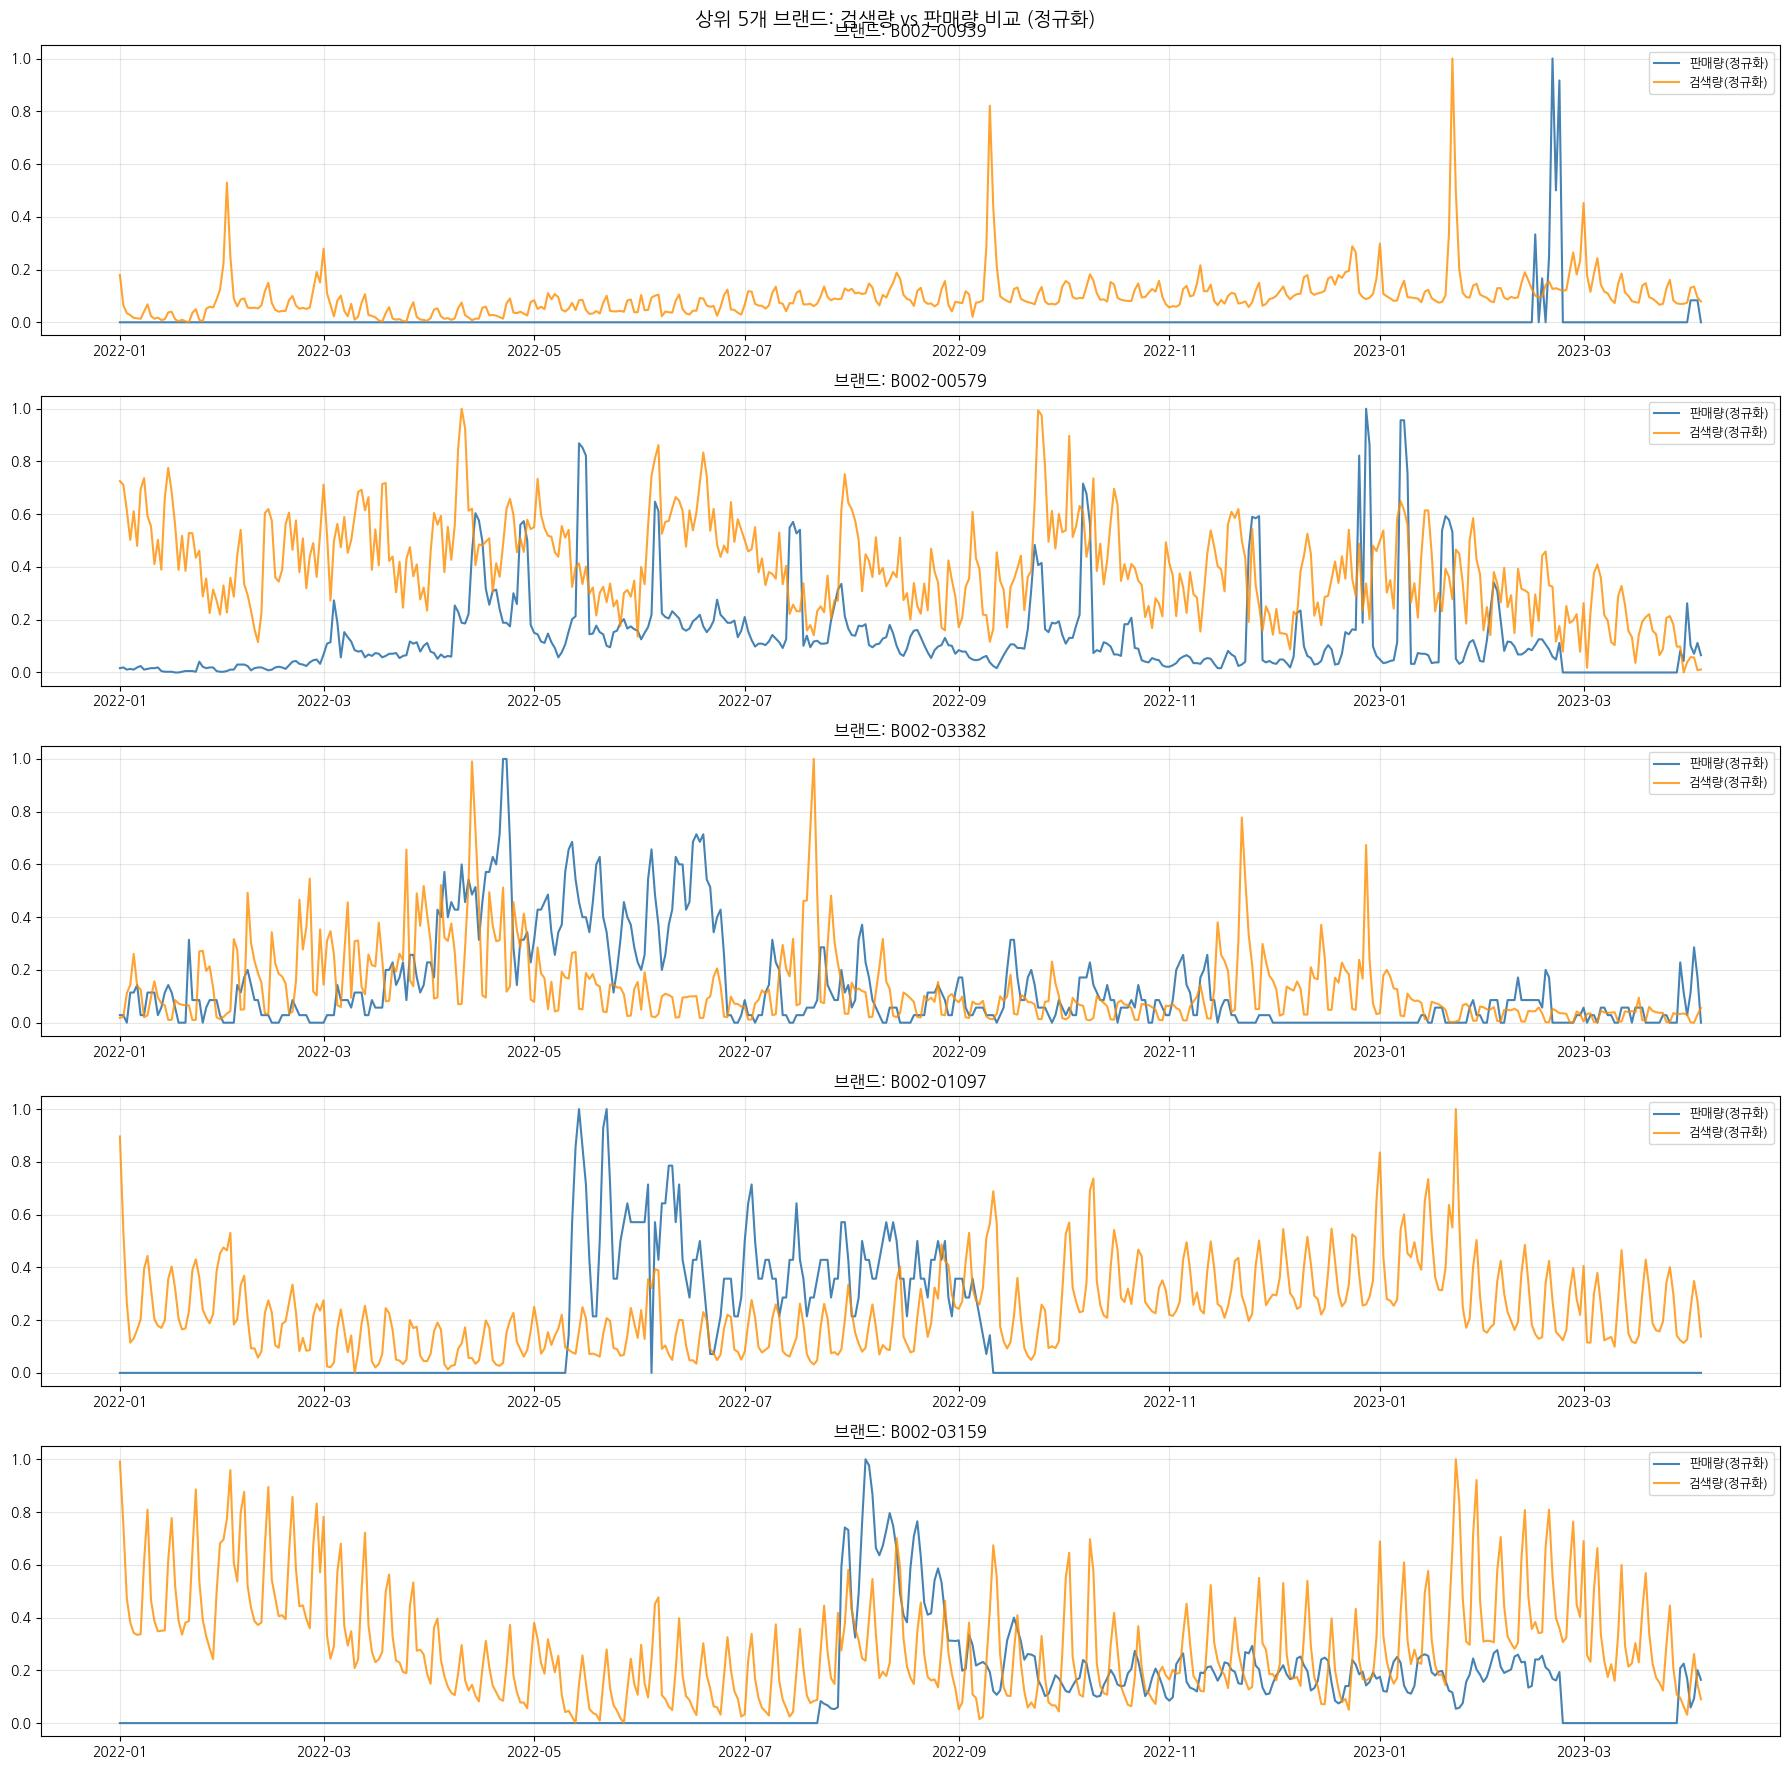

In [14]:
# ── 상위 5개 브랜드 검색량 vs 판매량 비교 ────────────────────────────────
brand_total_kw = keyword[KW_COLS].sum(axis=1)
top5_brands    = keyword.loc[brand_total_kw.nlargest(5).index, '브랜드'].values

def normalize(s):
    """0~1 범위로 정규화 — 스케일이 달라도 패턴을 나란히 비교할 수 있게"""
    return (s - s.min()) / (s.max() - s.min() + 1e-8)

fig, axes = plt.subplots(5, 1, figsize=(18, 18))
fig.suptitle('상위 5개 브랜드: 검색량 vs 판매량 비교 (정규화)', fontsize=14, fontweight='bold')

for i, brand in enumerate(top5_brands):
    ax = axes[i]
    kw_row    = keyword[keyword['브랜드'] == brand][KW_COLS].iloc[0]
    kw_ts     = pd.Series(kw_row.values, index=pd.to_datetime(KW_COLS))
    brand_qty = train[train['브랜드'] == brand][DATE_COLS].sum(axis=0)
    brand_qty.index = pd.to_datetime(brand_qty.index)
    ax.plot(normalize(brand_qty), color='steelblue',  lw=1.5, label='판매량(정규화)')
    ax.plot(normalize(kw_ts),    color='darkorange', lw=1.5, alpha=0.8, label='검색량(정규화)')
    ax.set_title(f'브랜드: {brand}')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### 💬 2-7 해석 — 검색량 피처 채택 결론

**전체 평균 상관계수 ≈ 0.02** → 통계적으로는 매우 약한 신호

그러나 브랜드별로 상관 방향이 다름:
- r = +0.47인 브랜드 존재 (강한 연동)
- r = -0.07인 브랜드 존재 (역방향)
- 평균을 내면 상쇄되어 0에 수렴 → 평균이 낮은 게 "쓸모없다"는 뜻이 아님

**→ 채택 결론: 전 브랜드에 보조 피처로 포함 (`kw_log`, `kw_lag_1`, `kw_lag_3`)**

근거:
1. 피처 3개 추가로 비용(계산량) 작음
2. LSTM은 예측력 없는 피처의 가중치를 자연스럽게 0으로 수렴시킴
3. 상관이 강한 브랜드(r > 0.2)에서 실질적 예측 향상 기대
4. 버리는 것보다 모델에게 판단을 맡기는 게 안전

### 2-8. ACF / PACF 분석 — 주간 주기성 확인

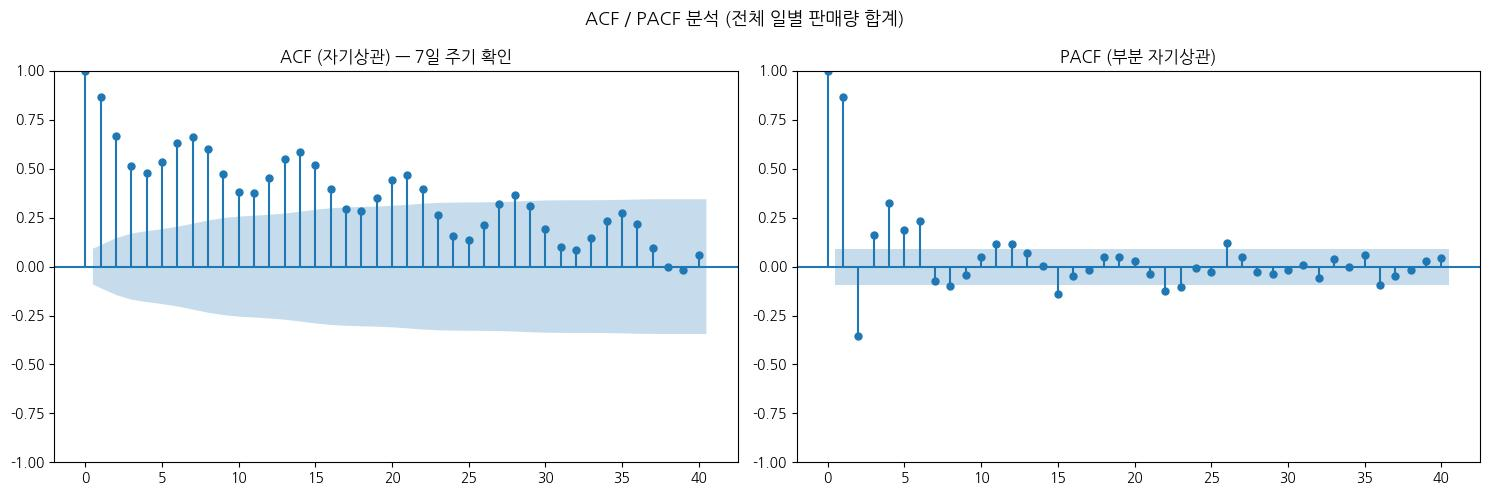

💡 모델링 활용: lag_1, lag_7, lag_14 피처 설계 근거


In [15]:
# ── ACF / PACF 분석 ────────────────────────────────────────────────────────
# ACF : 7일, 14일, 21일 간격으로 반복 → 주간 주기 확인
# PACF: Lag 1이 가장 높고 7일 지점에서 재상승 → lag_7 피처 설계 근거
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ACF / PACF 분석 (전체 일별 판매량 합계)', fontsize=13, fontweight='bold')
plot_acf(daily_total,  lags=40, ax=axes[0], title='ACF (자기상관) — 7일 주기 확인')
plot_pacf(daily_total, lags=40, ax=axes[1], title='PACF (부분 자기상관)')
plt.tight_layout()
plt.show()
print('💡 모델링 활용: lag_1, lag_7, lag_14 피처 설계 근거')

#### 💬 2-8 해석

**ACF:** 7일, 14일, 21일 간격으로 상관관계 반복 → 뚜렷한 주간 주기 존재  
**PACF:** Lag 1에서 최고 / 이후 급감 / 7일 지점에서 재상승  
**→ 모델 피처:** `lag_1`, `lag_7`, `lag_14` 설계 근거

### 2-9. Cross-Correlation (CCF) — 검색량 선행 효과 확인

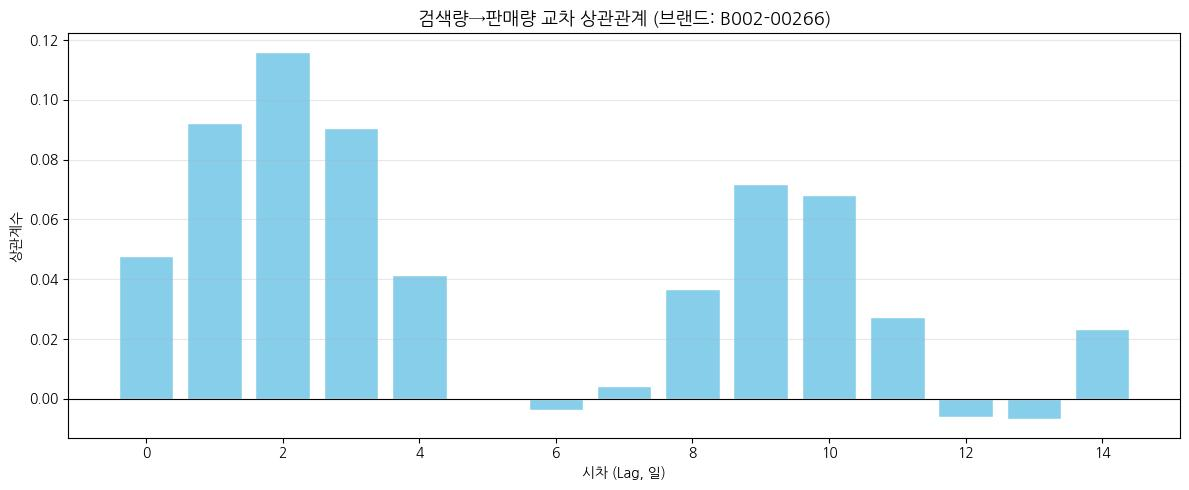

💡 모델링 활용: kw_lag_1, kw_lag_3 피처 설계 근거
   (단, 이는 단일 브랜드 기준 — 전체 평균은 2-7 참고)


In [16]:
# ── CCF — 검색량-판매량 교차 상관 (대표 브랜드 1개) ──────────────────────
# "검색 후 며칠 뒤에 구매가 일어나는가?" 를 확인하는 분석
from statsmodels.tsa.stattools import ccf

sample_brand       = train['브랜드'].value_counts().index[0]
brand_sales_series = train[train['브랜드'] == sample_brand][DATE_COLS].sum()
kw_row             = keyword[keyword['브랜드'] == sample_brand]

if len(kw_row) > 0:
    kw_series  = kw_row[KW_COLS].squeeze()
    common_len = min(len(brand_sales_series), len(kw_series))
    sales_arr  = brand_sales_series.values[:common_len].astype(float)
    kw_arr     = kw_series.values[:common_len].astype(float)

    cross_corr = ccf(sales_arr, kw_arr, adjusted=False)

    plt.figure(figsize=(12, 5))
    plt.bar(range(15), cross_corr[:15], color='skyblue', edgecolor='white')
    plt.axhline(0, color='black', lw=0.8)
    plt.title(f'검색량→판매량 교차 상관관계 (브랜드: {sample_brand})', fontsize=13)
    plt.xlabel('시차 (Lag, 일)'); plt.ylabel('상관계수')
    plt.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    print('💡 모델링 활용: kw_lag_1, kw_lag_3 피처 설계 근거')
    print('   (단, 이는 단일 브랜드 기준 — 전체 평균은 2-7 참고)')

#### 💬 2-9 해석

Lag 1~3에서 상관계수가 유지되는 패턴 → 검색 후 구매까지 **1~3일 고민 기간** 존재  
**→ `kw_lag_1`, `kw_lag_3` 피처 설계 근거**  
(단, 이는 단일 대표 브랜드 기준이며 전체 평균과 다를 수 있음)

### 2-10. 시계열 분해 (STL) — 추세·계절성·잔차 분리

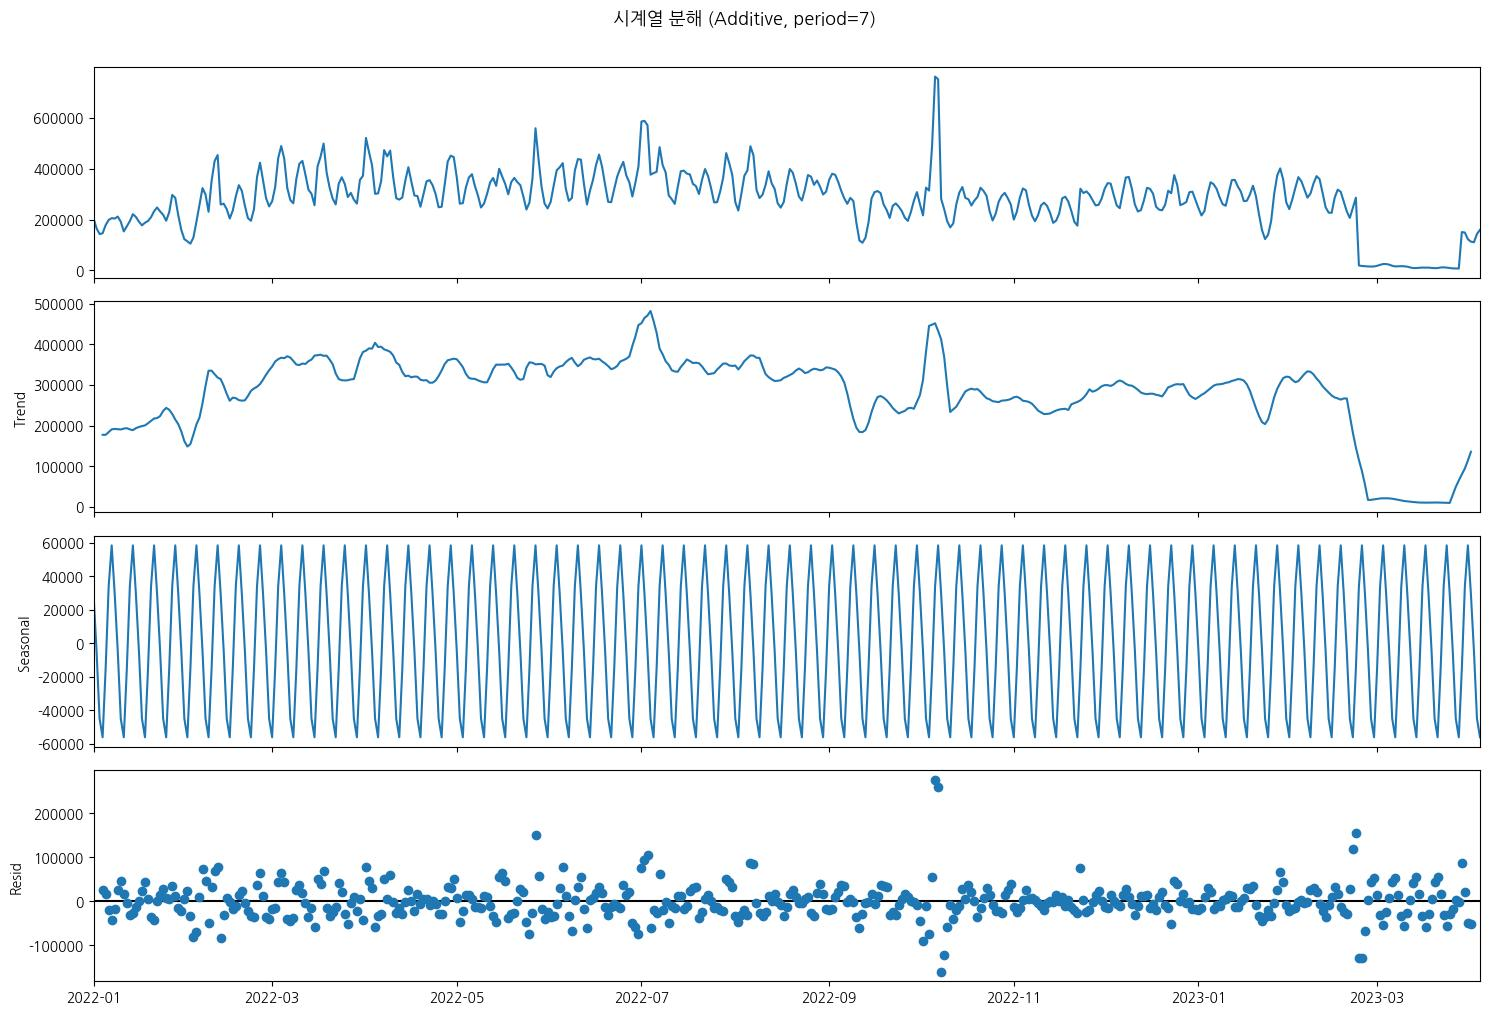

💡 Seasonal: 7일 주기 뚜렷 / Trend: 완만한 상승 후 급락 / Resid: 이벤트성 이상치


In [17]:
# ── STL 시계열 분해 ────────────────────────────────────────────────────────
# Trend(추세) + Seasonal(계절성) + Resid(잔차)로 분해해
# 각 성분의 크기와 패턴을 별도로 확인하는 분석
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(daily_total, model='additive', period=7)
fig = decomposition.plot()
fig.set_size_inches(15, 10)
fig.suptitle('시계열 분해 (Additive, period=7)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print('💡 Seasonal: 7일 주기 뚜렷 / Trend: 완만한 상승 후 급락 / Resid: 이벤트성 이상치')

#### 💬 2-10 해석

**Trend:** 완만한 상승 후 2023년 초 급락 → 2-3에서 발견한 급락 구간과 일치  
**Seasonal:** 7일 주기가 매우 뚜렷 → ACF 분석 결과와 일관  
**Resid:** 특정 날 잔차가 큰 구간 = 프로모션/이벤트 구간

### 2-11. ADF 정상성 검정 — 차분 필요 여부 확인

In [18]:
# ── ADF Test — 시계열이 "안정적"인지 확인 ─────────────────────────────────
# 정상성(Stationary): 평균·분산이 시간에 따라 변하지 않는 상태
# 비정상성이면 → log 변환 또는 차분으로 안정화 필요
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series, label=''):
    result     = adfuller(series)
    stationary = result[1] <= 0.05
    status     = '✅ 정상성(Stationary)' if stationary else '⚠️ 비정상성(Non-Stationary)'
    print(f'[{label}] ADF={result[0]:.4f}  p-value={result[1]:.4f}  → {status}')
    return stationary

print('=' * 55)
check_stationarity(daily_total,                 label='원본 데이터')
check_stationarity(daily_total.diff().dropna(), label='1차 차분')
print('=' * 55)
print('💡 비정상성 → log1p 변환으로 안정화 (STEP 3 적용 예정)')

[원본 데이터] ADF=-1.8483  p-value=0.3568  → ⚠️ 비정상성(Non-Stationary)
[1차 차분] ADF=-7.5020  p-value=0.0000  → ✅ 정상성(Stationary)
💡 비정상성 → log1p 변환으로 안정화 (STEP 3 적용 예정)


#### 💬 2-11 해석

원본이 비정상성이라면 → **log1p 변환**(STEP 3에서 적용)으로 안정화  
LSTM은 내부적으로 장기 패턴을 학습하므로 별도 차분은 불필요

### 2-12. 대분류별 시즌성 히트맵

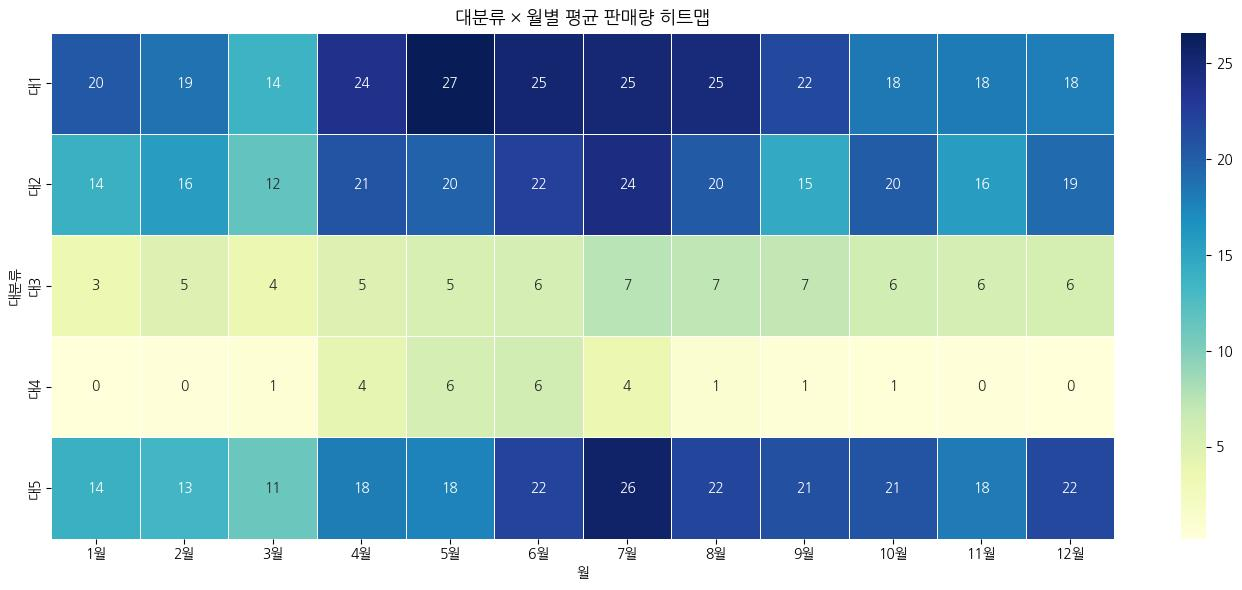

💡 카테고리별 시즌성이 다름 → 모델에 대분류 정보 강하게 반영 필요


In [19]:
# ── 대분류 × 월별 평균 판매량 히트맵 ─────────────────────────────────────
# 카테고리마다 잘 팔리는 달이 다른지 확인 (시즌성이 카테고리별로 다르면 임베딩 필요)
train_melted = train.melt(id_vars=['대분류'], value_vars=DATE_COLS,
                          var_name='date', value_name='qty')
train_melted['month'] = pd.to_datetime(train_melted['date']).dt.month
pivot = train_melted.pivot_table(index='대분류', columns='month', values='qty', aggfunc='mean')

# short_label 적용
pivot.index   = [cat_labels['대분류'].get(i, i) for i in pivot.index]
month_kor     = ['1월','2월','3월','4월','5월','6월','7월','8월','9월','10월','11월','12월']
pivot.columns = month_kor

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt='.0f', linewidths=0.5)
plt.title('대분류 × 월별 평균 판매량 히트맵', fontsize=13, fontweight='bold')
plt.xlabel('월'); plt.ylabel('대분류')
plt.tight_layout()
plt.show()
print('💡 카테고리별 시즌성이 다름 → 모델에 대분류 정보 강하게 반영 필요')

#### 💬 2-12 해석

카테고리마다 계절성 패턴이 다름 → 하나의 모델이 모든 카테고리를 학습하려면 카테고리 정보를 명시적으로 제공해야 함  
**→ `대분류_enc` 피처를 임베딩 레이어로 강하게 반영**

### 2-13. 한국 공휴일 vs 판매량

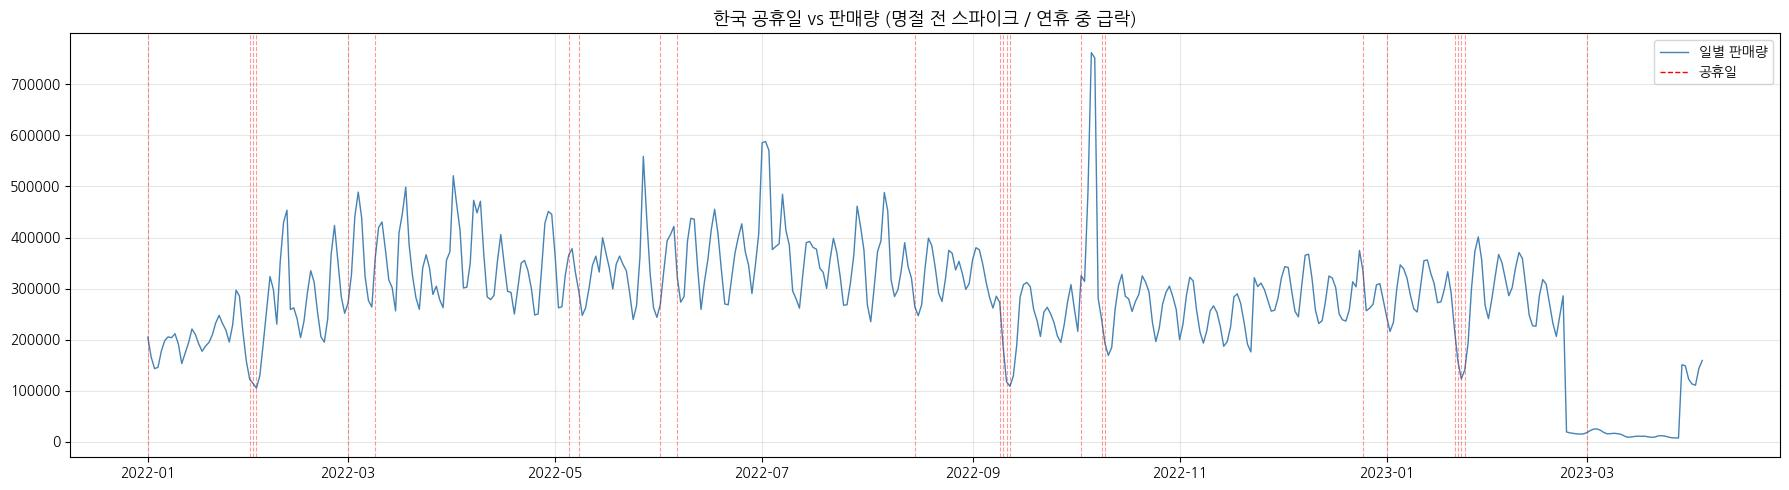

💡 공휴일 D-3 사전 구매 수요 → is_holiday, days_to_holiday 피처 설계 근거


In [20]:
# ── 한국 공휴일 vs 판매량 시각화 ─────────────────────────────────────────
# 명절 전: 사전 구매 수요 스파이크 / 명절 중: 판매 급락
# → is_holiday, days_to_holiday 피처 설계 근거
import holidays as hol

kr_holidays   = hol.KR(years=[2022, 2023])
holiday_dates = pd.to_datetime([str(d) for d in kr_holidays.keys()])
holiday_dates = holiday_dates[
    (holiday_dates >= daily_total.index.min()) &
    (holiday_dates <= daily_total.index.max())
]

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(daily_total.index, daily_total.values, color='steelblue', lw=1, label='일별 판매량')
for h in holiday_dates:
    ax.axvline(h, color='red', alpha=0.4, linestyle='--', lw=0.8)
ax.plot([], [], color='red', linestyle='--', lw=1, label='공휴일')
ax.set_title('한국 공휴일 vs 판매량 (명절 전 스파이크 / 연휴 중 급락)', fontsize=13)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('💡 공휴일 D-3 사전 구매 수요 → is_holiday, days_to_holiday 피처 설계 근거')

#### 💬 2-13 해석

**명절 전:** 사전 구매 수요 스파이크 (D-3 ~ D-7 구간)  
**명절 중:** 판매 급락 (V자형 골짜기)  
**→ `is_holiday`, `days_to_holiday` 피처로 이 패턴을 모델에게 알려줘야 함**

---
## 🗺️ EDA 요약 — STEP 3 전처리 결정사항

EDA에서 발견한 것들이 전처리 어떤 단계로 연결되는지 한눈에 정리

| 발견 사항 | → | 전처리 결정 | 담당 STEP |
|----------|---|------------|----------|
| 0이 63.8% + Long Tail 분포 | → | **log1p 변환** | 3-1 클리핑 후 적용 |
| 2023-02-20 이후 급락 구간 | → | **3방법 중 선택 처리** | 3-0 |
| Spike 제품 존재 | → | **중앙값×20 클리핑** | 3-1 |
| train(qty) + sales(revenue) 분리 | → | **단가(price) 파생** | 3-2 |
| 구조적 0 존재 (출시 전/단종) | → | **first_sale_date 기준 마스킹** | 3-4 |
| 검색량 보조 신호 (브랜드별 편차) | → | **kw_log, kw_lag_1, kw_lag_3 병합** | 3-6 |
| 요일·월 패턴 뚜렷 | → | **day_of_week, month 피처 추가** | 모델 입력 시 |
| 공휴일 전후 판매 패턴 | → | **is_holiday 플래그 추가** | 모델 입력 시 |

---
## STEP 3 — 데이터 전처리

> **전처리란?** EDA에서 발견한 문제들을 실제로 해결해 모델이 학습할 수 있는 형태로 만드는 과정입니다.

### 3-0. 급락 구간 처리 — 3가지 방법 선택 및 비교

```
OUTLIER_METHOD = 1  → 급락 기간 날짜 컬럼 자체를 학습에서 제외
OUTLIER_METHOD = 2  → 선형 보간 + 요일별 계절 지수로 값 교체
OUTLIER_METHOD = 3  → 원본 유지 + is_post_crash 플래그 생성 (모델이 직접 판단)
```

In [21]:
# ── 급락 구간 분석 ─────────────────────────────────────────────────────────
# ⚠️ CRASH_START, CRASH_END, daily_total 은 2-3에서 이미 정의됨
#
# 👇 아래 시각화(셀[56])에서 세 방법 결과를 비교한 뒤
#    이 값을 변경하고 셀[54]을 다시 실행하세요
# ⚙️  방법 선택 (1, 2, 3 중 하나) — 기본값은 3 (비교 후 변경)
OUTLIER_METHOD = 3   # ← 비교 후 여기서 최종 선택

crash_mask = (daily_total.index >= CRASH_START) & (daily_total.index <= CRASH_END)
normal_avg = daily_total[daily_total.index < CRASH_START].mean()
crash_avg  = daily_total[crash_mask].mean()

print('=' * 55)
print('📊 급락 구간 분석')
print('=' * 55)
print(f'  정상 구간 일평균  : {normal_avg:>10,.0f}')
print(f'  급락 구간 일평균  : {crash_avg:>10,.0f}')
print(f'  급락 비율         : {crash_avg/normal_avg:.1%}')
print(f'  급락 기간         : {CRASH_START.date()} ~ {CRASH_END.date()} ({crash_mask.sum()}일)')
print()
print('방법 안내:')
print('  Method 1 — 급락 기간 날짜 컬럼 자체를 학습에서 제외')
print('  Method 2 — 합성 데이터 복원 (전년 동기 실제값 × 성장률 보정)')
print('  Method 3 — 원본 유지 + is_post_crash 플래그 생성 (모델이 판단)')
print()
print('📌 아래 셀들을 순서대로 실행하세요:')
print('   1단계: 다음 셀(함수 정의) 실행')
print('   2단계: 비교 시각화 셀 실행 → 세 방법 결과 확인')
print('   3단계: 이 셀의 OUTLIER_METHOD 값을 원하는 방법으로 수정 후 재실행')
print('   4단계: 함수 정의 셀부터 다시 실행')
print()
print(f'⏳ 현재 임시 설정값: Method {OUTLIER_METHOD} (비교 전 기본값)')

📊 급락 구간 분석
  정상 구간 일평균  :    305,103
  급락 구간 일평균  :     49,274
  급락 비율         : 16.2%
  급락 기간         : 2023-02-20 ~ 2023-04-04 (44일)

방법 안내:
  Method 1 — 급락 기간 날짜 컬럼 자체를 학습에서 제외
  Method 2 — 합성 데이터 복원 (전년 동기 실제값 × 성장률 보정)
  Method 3 — 원본 유지 + is_post_crash 플래그 생성 (모델이 판단)

📌 아래 셀들을 순서대로 실행하세요:
   1단계: 다음 셀(함수 정의) 실행
   2단계: 비교 시각화 셀 실행 → 세 방법 결과 확인
   3단계: 이 셀의 OUTLIER_METHOD 값을 원하는 방법으로 수정 후 재실행
   4단계: 함수 정의 셀부터 다시 실행

⏳ 현재 임시 설정값: Method 3 (비교 전 기본값)


In [22]:
# # ── 급락 구간 분석 ─────────────────────────────────────────────────────────
# # ⚠️ CRASH_START, CRASH_END, daily_total 은 2-3에서 이미 정의됨

# # ⚙️  여기서 방법 선택 (1, 2, 3 중 하나)
# OUTLIER_METHOD = 3

# crash_mask = (daily_total.index >= CRASH_START) & (daily_total.index <= CRASH_END)
# normal_avg = daily_total[daily_total.index < CRASH_START].mean()
# crash_avg  = daily_total[crash_mask].mean()

# print('=' * 55)
# print('📊 급락 구간 분석')
# print('=' * 55)
# print(f'  정상 구간 일평균  : {normal_avg:>10,.0f}')
# print(f'  급락 구간 일평균  : {crash_avg:>10,.0f}')
# print(f'  급락 비율         : {crash_avg/normal_avg:.1%}')
# print(f'  급락 기간         : {CRASH_START.date()} ~ {CRASH_END.date()} ({crash_mask.sum()}일)')
# print()
# print('방법 안내:')
# print('  Method 1 — 급락 기간 날짜 컬럼 자체를 학습에서 제외')
# print('  Method 2 — 선형 보간 + 요일별 계절 지수로 값 교체')
# print('  Method 3 — 원본 유지 + is_post_crash 플래그 생성 (모델이 판단)')
# print(f'\n✅ 선택된 방법: Method {OUTLIER_METHOD}')

### 🔧 함수 선언 — `apply_method1`, `apply_method2`, `apply_method3`

급락 구간을 처리하는 3가지 함수입니다.  
위 셀의 `OUTLIER_METHOD` 변수 값에 따라 하나만 실제로 적용됩니다.

| 함수 | 입력 | 출력 |
|------|------|------|
| `apply_method1` | train_df, date_cols, crash_start, crash_end | (train_out, date_cols_out) |
| `apply_method2` | train_df, date_cols, crash_start, crash_end | (train_out, date_cols) |
| `apply_method3` | train_df, date_cols, crash_start, crash_end | (train_out, date_cols, crash_flag_dict) |

In [23]:
# ── 3가지 방법 함수 정의 ───────────────────────────────────────────────────

def apply_method1(train_df, date_cols, crash_start, crash_end):
    """급락 기간 날짜 컬럼을 학습에서 제외 — 가장 단순하지만 데이터 손실"""
    crash_cols    = [c for c in date_cols if crash_start <= pd.Timestamp(c) <= crash_end]
    train_out     = train_df.drop(columns=crash_cols)
    date_cols_out = [c for c in date_cols if c not in crash_cols]
    print(f'[Method 1] 제외 날짜: {len(crash_cols)}일 → 잔여 학습일: {len(date_cols_out)}일')
    return train_out, date_cols_out

def apply_method2(train_df, date_cols, crash_start, crash_end):
    """선형 보간 + 요일별 계절 지수로 급락 구간 값 교체 — 데이터 유지, 가상 복원"""
    train_out   = train_df.copy()
    date_index  = pd.to_datetime(date_cols)
    crash_mask  = (date_index >= crash_start) & (date_index <= crash_end)
    crash_cols  = [c for c, m in zip(date_cols, crash_mask) if m]
    normal_cols = [c for c, m in zip(date_cols, crash_mask) if not m]

    # 정상 구간 요일별 평균 비율 (계절 지수)
    normal_daily  = train_df[normal_cols].sum(axis=0)
    normal_series = pd.Series(normal_daily.values, index=pd.to_datetime(normal_cols))
    dow_ratio     = normal_series.groupby(normal_series.index.dayofweek).mean()
    dow_ratio     = dow_ratio / dow_ratio.mean()   # 정규화

    pre_val  = train_df[normal_cols[-1]]
    post_val = train_df[normal_cols[0]]

    for i, col in enumerate(crash_cols):
        t               = (i + 1) / (len(crash_cols) + 1)
        interp          = pre_val * (1 - t) + post_val * t
        dow             = pd.Timestamp(col).dayofweek
        seasonal_factor = dow_ratio.get(dow, 1.0)
        train_out[col]  = (interp * seasonal_factor).round().clip(lower=0)

    print(f'[Method 2] 선형 보간 + 계절 보정 완료: {len(crash_cols)}일')
    return train_out, date_cols

def apply_method3(train_df, date_cols, crash_start, crash_end):
    """원본 유지 + is_post_crash 플래그 생성 — 모델이 급락 패턴을 직접 학습"""
    crash_flag = {c: int(pd.Timestamp(c) >= crash_start) for c in date_cols}
    n_crash    = sum(crash_flag.values())
    print(f'[Method 3] 원본 유지, is_post_crash 플래그 생성 (급락 후: {n_crash}일)')
    return train_df.copy(), date_cols, crash_flag

# ── 선택한 방법 적용 ────────────────────────────────────────────────────────
if OUTLIER_METHOD == 1:
    train_m, DATE_COLS_M = apply_method1(train, DATE_COLS, CRASH_START, CRASH_END)
    crash_flag_dict = {}
elif OUTLIER_METHOD == 2:
    train_m, DATE_COLS_M = apply_method2(train, DATE_COLS, CRASH_START, CRASH_END)
    crash_flag_dict = {}
else:
    train_m, DATE_COLS_M, crash_flag_dict = apply_method3(train, DATE_COLS, CRASH_START, CRASH_END)

print(f'\n✅ Method {OUTLIER_METHOD} 적용 완료  /  학습 날짜 수: {len(DATE_COLS_M)}일')

[Method 3] 원본 유지, is_post_crash 플래그 생성 (급락 후: 44일)

✅ Method 3 적용 완료  /  학습 날짜 수: 459일


[Method 1] 제외 날짜: 44일 → 잔여 학습일: 415일
[Method 2] 선형 보간 + 계절 보정 완료: 44일
[Method 3] 원본 유지, is_post_crash 플래그 생성 (급락 후: 44일)


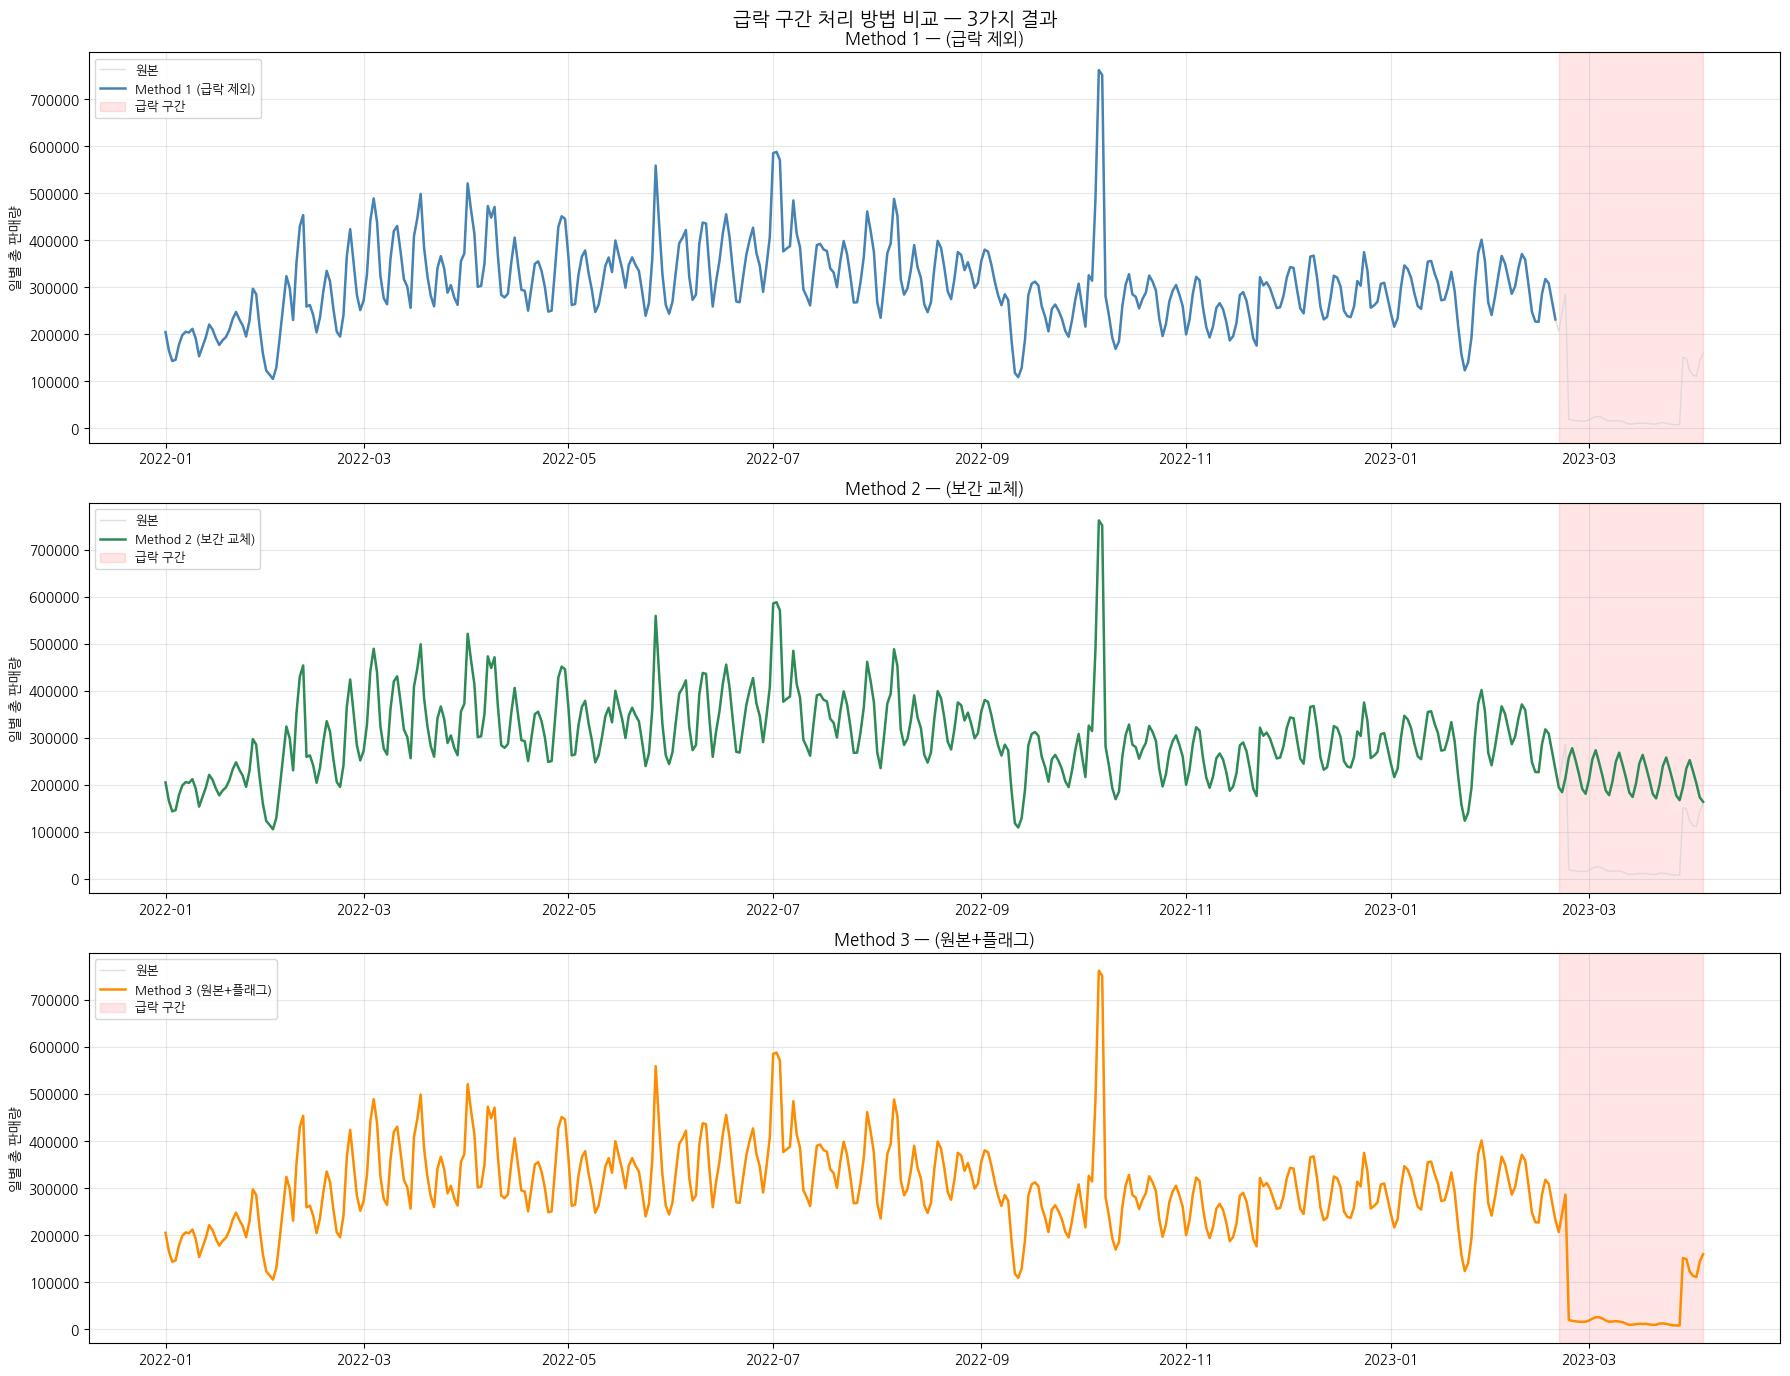


→ 현재 선택: Method 3 (위 셀 OUTLIER_METHOD 변수에서 변경 가능)


In [24]:
# ── 3가지 방법 결과 나란히 비교 시각화 ────────────────────────────────────
# 선택 전에 세 방법의 결과가 얼마나 다른지 눈으로 확인
results = {}

t1, dc1 = apply_method1(train, DATE_COLS, CRASH_START, CRASH_END)
d1 = t1[dc1].sum(axis=0); d1.index = pd.to_datetime(dc1)
results['Method 1\n(급락 제외)'] = (d1, 'steelblue')

t2, dc2 = apply_method2(train, DATE_COLS, CRASH_START, CRASH_END)
d2 = t2[dc2].sum(axis=0); d2.index = pd.to_datetime(dc2)
results['Method 2\n(보간 교체)'] = (d2, 'seagreen')

t3, dc3, _ = apply_method3(train, DATE_COLS, CRASH_START, CRASH_END)
d3 = t3[dc3].sum(axis=0); d3.index = pd.to_datetime(dc3)
results['Method 3\n(원본+플래그)'] = (d3, 'darkorange')

fig, axes = plt.subplots(3, 1, figsize=(18, 14))
fig.suptitle('급락 구간 처리 방법 비교 — 3가지 결과', fontsize=14, fontweight='bold')

for ax, (label, (series, color)) in zip(axes, results.items()):
    ax.plot(daily_total.index, daily_total.values, color='lightgray', lw=1,
            label='원본', alpha=0.7)
    ax.plot(series.index, series.values, color=color, lw=1.8,
            label=label.replace('\n', ' '))
    ax.axvspan(CRASH_START, CRASH_END, alpha=0.1, color='red', label='급락 구간')
    ax.set_title(label.replace('\n', ' — '), fontsize=12)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylabel('일별 총 판매량')

plt.tight_layout()
plt.show()
print(f'\n→ 현재 선택: Method {OUTLIER_METHOD} (위 셀 OUTLIER_METHOD 변수에서 변경 가능)')

### 3-1. Spike 클리핑 — 개별 제품 이상치 제거

In [25]:
# ── Spike 클리핑 (중앙값 × 20 상한선) ────────────────────────────────────
# 완전 제거 대신 상한선으로 깎기 → 패턴은 유지, 극단값의 학습 지배만 방지
#
# 중앙값 × 20 근거:
#   - 정상 판매일의 최대치가 평균의 10~15배 수준임을 EDA(2-5)에서 확인
#   - 여유를 두어 20배로 설정 → 실제 이벤트성 판매는 유지, 데이터 오류만 제거
CLIP_FACTOR = 20

train_clean = train_m.copy()
train_clean[DATE_COLS_M] = train_clean[DATE_COLS_M].astype(float)

product_medians = train_clean[DATE_COLS_M].median(axis=1)
clipped_count   = 0

for idx, row_median in product_medians.items():
    if row_median == 0:
        # 중앙값이 0인 제품은 95% 분위수를 상한으로 사용
        upper_limit = train_clean.loc[idx, DATE_COLS_M].quantile(0.95)
        if upper_limit == 0:
            continue
    else:
        upper_limit = row_median * CLIP_FACTOR

    before_max = train_clean.loc[idx, DATE_COLS_M].max()
    train_clean.loc[idx, DATE_COLS_M] = train_clean.loc[idx, DATE_COLS_M].clip(upper=upper_limit)
    if before_max > train_clean.loc[idx, DATE_COLS_M].max():
        clipped_count += 1

print(f'클리핑된 제품 수: {clipped_count:,}개')
# print(f'클리핑 전 최대값 : {train[DATE_COLS_M].values.max():,}') #아래 코드로 수정
print(f'클리핑 전 최대값 : {train_m[DATE_COLS_M].values.max():,}')
print(f'클리핑 후 최대값 : {train_clean[DATE_COLS_M].values.max():,.1f}')
print('✅ 원본: train  /  클린버전: train_clean')


클리핑된 제품 수: 8,472개
클리핑 전 최대값 : 200,420
클리핑 후 최대값 : 38,384.0
✅ 원본: train  /  클린버전: train_clean


### 3-2. 단가(Price) 파생 — revenue ÷ qty

In [26]:
# ── 단가 파생 ─────────────────────────────────────────────────────────────
# sales.csv = 매출액(revenue) / train.csv = 판매량(qty)
# → 단가 = revenue ÷ qty → 가격 변동이 판매에 미치는 영향을 피처로 활용
# qty = 0인 날은 단가를 계산할 수 없으므로 NaN 처리 후 해당 제품의 중앙값으로 보간
price_df = sales[META_COLS].copy()

for col in DATE_COLS_M:
    price_df[col] = np.where(
        train_clean[col] > 0,
        sales[col] / train_clean[col],   # 단가 계산
        np.nan                            # 판매 없는 날은 NaN
    )

# 제품별 중앙 단가로 NaN 보간
price_median = price_df[DATE_COLS_M].median(axis=1)
for col in DATE_COLS_M:
    price_df[col] = price_df[col].fillna(price_median)

print(f'NaN 비율 (보간 후): {price_df[DATE_COLS_M].isna().mean().mean():.4%}')
print('✅ price_df 생성 완료')

NaN 비율 (보간 후): 0.5349%
✅ price_df 생성 완료


### 3-3. Wide → Long 변환 + 체크포인트

현재 데이터는 **Wide 포맷** (제품 1행 × 날짜 459열) 입니다.  
LSTM 학습을 위해 **Long 포맷** (제품×날짜 1행) 으로 변환합니다.

```
Wide:  [제품A | 2022-01-01 | 2022-01-02 | ... ]  →  1행
Long:  [제품A | 2022-01-01 | qty=10     ]  →  1행
       [제품A | 2022-01-02 | qty=5      ]  →  1행
```

In [27]:
# ── Wide → Long 변환 ───────────────────────────────────────────────────────
print('Wide → Long 변환 중... (약 30초~1분 소요)')

df = pd.melt(
    train_clean,
    id_vars    = META_COLS,
    value_vars = DATE_COLS_M,
    var_name   = 'date',
    value_name = 'qty'
)

price_long = pd.melt(
    price_df,
    id_vars    = META_COLS,
    value_vars = DATE_COLS_M,
    var_name   = 'date',
    value_name = 'price'
)

df['date']         = pd.to_datetime(df['date'])
price_long['date'] = pd.to_datetime(price_long['date'])

# qty + price 병합
df = df.merge(price_long[['ID', 'date', 'price']], on=['ID', 'date'], how='left')
df = df.sort_values(['ID', 'date']).reset_index(drop=True)

# Method 3일 때 is_post_crash 플래그 병합
if OUTLIER_METHOD == 3 and crash_flag_dict:
    flag_df = pd.DataFrame([
        {'date': pd.Timestamp(c), 'is_post_crash': v}
        for c, v in crash_flag_dict.items()
    ])
    df = df.merge(flag_df, on='date', how='left')
    df['is_post_crash'] = df['is_post_crash'].fillna(0).astype(int)
    print(f'  is_post_crash 플래그 추가 (급락후=1): {df["is_post_crash"].sum():,}행')
else:
    df['is_post_crash'] = 0

print(f'변환 완료: {train_clean.shape} → {df.shape}')

Wide → Long 변환 중... (약 30초~1분 소요)
  is_post_crash 플래그 추가 (급락후=1): 699,160행
변환 완료: (15890, 467) → (7293510, 10)


In [28]:
# ── 중간 체크포인트 — 현재 df 상태 확인 ──────────────────────────────────
print('=' * 55)
print('📋 Wide → Long 변환 후 df 상태')
print('=' * 55)
print(f'  Shape     : {df.shape}')
print(f'  컬럼 목록  : {list(df.columns)}')
print(f'  날짜 범위  : {df["date"].min().date()} ~ {df["date"].max().date()}')
print(f'  제품 수    : {df["ID"].nunique():,}개')
print(f'  qty 결측치 : {df["qty"].isna().sum()}')
print()
df.head(3)

📋 Wide → Long 변환 후 df 상태
  Shape     : (7293510, 10)
  컬럼 목록  : ['ID', '제품', '대분류', '중분류', '소분류', '브랜드', 'date', 'qty', 'price', 'is_post_crash']
  날짜 범위  : 2022-01-01 ~ 2023-04-04
  제품 수    : 15,890개
  qty 결측치 : 0



,ID,제품,대분류,중분류,소분류,브랜드,date,qty,price,is_post_crash
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,2022-01-01,0.0,5600.0,0
1,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,2022-01-02,0.0,5600.0,0
2,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,2022-01-03,0.0,5600.0,0


### 3-4. 구조적 0 마스킹

In [29]:
# ── 구조적 0 마스킹 ────────────────────────────────────────────────────────
# ⚠️ first_sale_date, last_sale_date, has_sales 는 EDA 2-6에서 생성됨
#    → EDA 셀을 먼저 실행해야 이 셀이 정상 작동합니다.

df = df.merge(
    train[['ID', 'first_sale_date', 'last_sale_date']],
    on='ID', how='left'
)

DISC_BUFFER = 90  # 마지막 판매일 이후 90일까지는 "진짜 0"으로 취급, 이후는 구조적 0

df['is_structural_zero'] = (
    (df['date'] < df['first_sale_date']) |
    (df['date'] > df['last_sale_date'] + pd.Timedelta(days=DISC_BUFFER))
)

print('=' * 55)
print('📊 구조적 0 마스킹 결과')
print('=' * 55)
print(f'  전체 행 수                : {len(df):>10,}')
print(f'  구조적 0 마스킹 행 수     : {df["is_structural_zero"].sum():>10,}')
useful_rows = ~df['is_structural_zero']
print(f'  학습 활용 가능 행         : {useful_rows.sum():>10,}')
print(f'  전체 대비 비율            : {useful_rows.mean():.1%}')
print()
print(f'  한 번도 안 팔린 제품 수   : {(~has_sales).sum():,}개')
print('  → 이 제품들은 first_sale_date = NaT → 전체 기간이 구조적 0으로 마스킹됨')

📊 구조적 0 마스킹 결과
  전체 행 수                :  7,293,510
  구조적 0 마스킹 행 수     :  2,216,596
  학습 활용 가능 행         :  5,076,914
  전체 대비 비율            : 69.6%

  한 번도 안 팔린 제품 수   : 85개
  → 이 제품들은 first_sale_date = NaT → 전체 기간이 구조적 0으로 마스킹됨


### 3-5. 카테고리 인코딩 — 텍스트 → 숫자

### 🔧 함수/객체 선언 — `LabelEncoder` (le_dict)

카테고리 텍스트를 숫자로 변환하는 `LabelEncoder` 객체들입니다.  
`le_dict`에 저장해 두면 나중에 예측 결과를 원래 이름으로 **역변환**할 때 사용합니다.

In [30]:
from sklearn.preprocessing import LabelEncoder

# ── LabelEncoder 카테고리 인코딩 ──────────────────────────────────────────
# 딥러닝 모델은 텍스트를 그대로 받을 수 없음 → 숫자로 변환 필요
# LabelEncoder: '대1' → 0, '대2' → 1, ... 식으로 정수 부여
le_dict = {}

for col in ['대분류', '중분류', '소분류', '브랜드']:
    le = LabelEncoder()
    df[f'{col}_enc'] = le.fit_transform(df[col].astype(str))
    le_dict[col]     = le
    print(f'  {col:5s}: {len(le.classes_):>5,}개 클래스 → 0~{len(le.classes_)-1}')

le_product = LabelEncoder()
df['product_enc'] = le_product.fit_transform(df['ID'].astype(str))
le_dict['product'] = le_product
print(f"  {'제품':5s}: {len(le_product.classes_):>5,}개 클래스 인코딩")
print('\n✅ le_dict에 각 LabelEncoder 저장 완료 (예측 시 역변환에 사용)')

  대분류  :     5개 클래스 → 0~4
  중분류  :    11개 클래스 → 0~10
  소분류  :    53개 클래스 → 0~52
  브랜드  : 3,170개 클래스 → 0~3169
  제품   : 15,890개 클래스 인코딩

✅ le_dict에 각 LabelEncoder 저장 완료 (예측 시 역변환에 사용)


### 3-6. 브랜드 검색량 병합 — kw_log / kw_lag_1 / kw_lag_3

### 🔧 파생 변수 안내

| 변수명 | 계산 방법 | 의미 |
|--------|----------|------|
| `kw_log` | log1p(kw_cnt) | 당일 검색량 (log 변환) |
| `kw_lag_1` | kw_log를 1일 shift | 하루 전 검색량 |
| `kw_lag_3` | kw_log를 3일 shift | 3일 전 검색량 |

In [31]:
# ── 검색량 처리 및 병합 ────────────────────────────────────────────────────
# 흐름: kw_cnt → 99% cap 클리핑 → log1p → kw_log → shift → lag 피처

# 1. Wide → Long 변환
kw_long = pd.melt(
    keyword,
    id_vars    = ['브랜드'],
    value_vars = KW_COLS,
    var_name   = 'date',
    value_name = 'kw_cnt'
)
kw_long['date']   = pd.to_datetime(kw_long['date'])
kw_long['kw_cnt'] = kw_long['kw_cnt'].fillna(0)

# 2. 브랜드별 99% cap 클리핑 → 극단 이상치 제거
cap_by_brand = kw_long.groupby('브랜드')['kw_cnt'].quantile(0.99)
kw_long = kw_long.join(cap_by_brand.rename('cap'), on='브랜드')
kw_long['kw_cnt'] = kw_long[['kw_cnt', 'cap']].min(axis=1)
kw_long.drop(columns=['cap'], inplace=True)

# 3. log1p 변환
kw_long['kw_log'] = np.log1p(kw_long['kw_cnt'])

# 4. 브랜드 내 시간순 정렬 후 shift → lag 피처
# lag_2 제외: lag_1과 정보 중복이 크고 lag_3로 충분히 커버
kw_long = kw_long.sort_values(['브랜드', 'date']).reset_index(drop=True)
kw_long['kw_lag_1'] = kw_long.groupby('브랜드')['kw_log'].shift(1).fillna(0)
kw_long['kw_lag_3'] = kw_long.groupby('브랜드')['kw_log'].shift(3).fillna(0)

# 5. df에 병합
df = df.merge(
    kw_long[['브랜드', 'date', 'kw_log', 'kw_lag_1', 'kw_lag_3']],
    on=['브랜드', 'date'], how='left'
)
df[['kw_log', 'kw_lag_1', 'kw_lag_3']] = df[['kw_log', 'kw_lag_1', 'kw_lag_3']].fillna(0)

print(f'kw_log    NaN: {df["kw_log"].isna().sum()}')
print(f'kw_lag_1  NaN: {df["kw_lag_1"].isna().sum()}')
print(f'kw_lag_3  NaN: {df["kw_lag_3"].isna().sum()}')
print(f'kw_log > 0 비율: {(df["kw_log"] > 0).mean():.1%}')
print('\n✅ 검색량 피처 3개 추가 완료: kw_log, kw_lag_1, kw_lag_3')

kw_log    NaN: 0
kw_lag_1  NaN: 0
kw_lag_3  NaN: 0
kw_log > 0 비율: 77.3%

✅ 검색량 피처 3개 추가 완료: kw_log, kw_lag_1, kw_lag_3


### 3-7. 최종 df 확인

In [32]:
# ── 최종 전처리 완료 요약 ─────────────────────────────────────────────────
print('=' * 60)
print('✅ STEP 3 전처리 완료!')
print('=' * 60)
print(f'  최종 df shape  : {df.shape}')
print(f'  날짜 범위      : {df["date"].min().date()} ~ {df["date"].max().date()}')
print(f'  제품 수        : {df["ID"].nunique():,}개')
print(f'  qty 결측치     : {df["qty"].isna().sum()}')
print()

print('=' * 60)
print('📋 최종 피처 목록')
print('=' * 60)
feature_groups = {
    '식별자'      : ['ID', 'date'],
    '타겟'        : ['qty'],
    '카테고리'    : ['대분류_enc', '중분류_enc', '소분류_enc', '브랜드_enc', 'product_enc'],
    '가격'        : ['price'],
    '검색량'      : ['kw_log', 'kw_lag_1', 'kw_lag_3'],
    '마스크/플래그': ['is_structural_zero', 'is_post_crash'],
}
for group, cols in feature_groups.items():
    avail = [c for c in cols if c in df.columns]
    print(f'  [{group}] {avail}')

print()
df.head(3)

✅ STEP 3 전처리 완료!
  최종 df shape  : (7293510, 21)
  날짜 범위      : 2022-01-01 ~ 2023-04-04
  제품 수        : 15,890개
  qty 결측치     : 0

📋 최종 피처 목록
  [식별자] ['ID', 'date']
  [타겟] ['qty']
  [카테고리] ['대분류_enc', '중분류_enc', '소분류_enc', '브랜드_enc', 'product_enc']
  [가격] ['price']
  [검색량] ['kw_log', 'kw_lag_1', 'kw_lag_3']
  [마스크/플래그] ['is_structural_zero', 'is_post_crash']



,ID,제품,대분류,중분류,소분류,브랜드,date,qty,price,is_post_crash,...,last_sale_date,is_structural_zero,대분류_enc,중분류_enc,소분류_enc,브랜드_enc,product_enc,kw_log,kw_lag_1,kw_lag_3
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,2022-01-01,0.0,5600.0,0,...,2023-02-10,True,1,6,37,0,0,0.610477,0.000000,0.0
1,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,2022-01-02,0.0,5600.0,0,...,2023-02-10,True,1,6,37,0,0,0.649106,0.610477,0.0
2,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,2022-01-03,0.0,5600.0,0,...,2023-02-10,True,1,6,37,0,0,0.896304,0.649106,0.0
